![Final Qatar 2022](https://i.ytimg.com/vi/wmb457AN5mA/maxresdefault.jpg)

# 🏆 Análisis de la Final del Mundial Qatar 2022
## Argentina vs. Francia — Ciencia de Datos Aplicada al Fútbol

**Partido:** Final FIFA World Cup Qatar 2022  
**Fecha:** 18 de diciembre de 2022  
**Estadio:** Lusail Iconic Stadium, Qatar  
**Resultado:** Argentina 3 — 3 Francia (Argentina ganó 4-2 en tanda de penales)

Este partido es considerado por muchos analistas como la final más dramática en la historia
de los mundiales. Tres goles en once minutos de la segunda mitad, prórroga completa,
y definición por penales lo convierten en un caso de estudio ideal para aplicar ciencia
de datos: la narrativa del partido está llena de cambios de momentum que los datos
pueden cuantificar y visualizar con precisión.

---

## Fuente de Datos

Los datos provienen del repositorio abierto de **StatsBomb**, una de las empresas
líderes mundiales en analítica de fútbol. StatsBomb libera gratuitamente datos de
eventos atómicos de competiciones seleccionadas para uso académico e investigativo.
Cada fila del dataset representa una acción individual del partido (pase, tiro,
presión, conducción) con coordenadas espaciales exactas, marca de tiempo en
milisegundos y atributos específicos del evento.

Repositorio oficial: https://github.com/statsbomb/open-data

---

## Herramientas Utilizadas

- Python 3
- pandas
- numpy
- matplotlib
- mplsoccer
- XGBoost
- Plotly
- seaborn
- IPython.display

---

## Hipótesis del Proyecto

Este análisis busca responder cinco preguntas concretas sobre el partido:

1. ¿Qué equipo generó mayor peligro real medido en xG durante los 120 minutos
   de juego, y cómo evolucionó esa amenaza a lo largo del partido?

2. ¿Cómo se distribuyó la presión defensiva de cada equipo en el campo,
   y qué zonas concentraron mayor intensidad táctica?

3. ¿Cuál fue la cadena de posesión más veloz de Argentina en términos de
   progresión vertical, y qué jugadores la protagonizaron?

4. ¿Qué diferencias tácticas revela la red de pases del once inicial de
   Argentina antes de la primera sustitución?

5. ¿Quién tuvo un rendimiento individual superior en las métricas ofensivas
   clave del partido: Messi o Mbappé?

In [ ]:
# ============================================================
# BLOQUE 1 — Configuración del Entorno
# ============================================================
# Librerías que no vienen preinstaladas en Google Colab:
# mplsoccer : lienzo especializado para visualizaciones de fútbol
# xgboost   : modelo de ensamble para calcular goles esperados (xG)
# ============================================================

!pip install mplsoccer xgboost --quiet

# ============================================================
# Importaciones del proyecto
# ============================================================

import pandas as pd               # Manipulación de datos tabulares
import numpy as np                # Operaciones vectoriales y cálculo numérico
import matplotlib.pyplot as plt   # Visualización base
import matplotlib.patches as mpatches  # Elementos gráficos adicionales
import seaborn as sns             # Mapas de calor y estadística visual
import plotly.graph_objects as go # Gráficos interactivos (Radar)
import xgboost as xgb             # Modelo predictivo de goles esperados

from mplsoccer import Pitch       # Lienzo de campo de fútbol
from IPython.display import display, HTML  # Renderizado de tablas ejecutivas

# ============================================================
# Configuración global
# ============================================================

# Suprime advertencias de asignación encadenada de pandas
pd.options.mode.chained_assignment = None

print("Entorno configurado correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.0 MB/s eta 0:00:00
✅ Entorno configurado correctamente.


## BLOQUE 2: Ingesta del Pipeline Relacional StatsBomb

El pipeline sigue una estructura jerárquica de tres niveles que deben
recorrerse en orden secuencial. Cada nivel depende del anterior para
construir la llave de acceso al siguiente dataset.

**Nivel 1 — Competiciones:** Identifica `competition_id` y `season_id` de Qatar 2022.  
**Nivel 2 — Partidos:** Usa esas llaves para localizar el `match_id` de la Final.  
**Nivel 3 — Eventos:** Usa el `match_id` para cargar los 4,407 eventos atómicos del partido.

#### Celda 1: Configuración de la URL base y carga del catálogo de competiciones

In [ ]:
# Define la URL base del repositorio abierto de StatsBomb en GitHub.
# Todos los datasets del proyecto se construyen concatenando esta raíz
# con la ruta específica de cada archivo.
BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/"

# Carga el catálogo completo de competiciones disponibles en StatsBomb
url_competiciones = BASE_URL + "competitions.json"
df_competiciones  = pd.read_json(url_competiciones)

# Auditoría volumétrica y estructural del catálogo
print(f"Estructura: {df_competiciones.shape[0]} competiciones disponibles, "
      f"{df_competiciones.shape[1]} columnas.")
print(f"\nColumnas: {df_competiciones.columns.tolist()}")
print(f"\nNulos por columna:\n{df_competiciones.isnull().sum()}")

Estructura: 80 competiciones disponibles, 12 columnas.

Columnas: ['competition_id', 'season_id', 'country_name', 'competition_name', 'competition_gender', 'competition_youth', 'competition_international', 'season_name', 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']

Nulos por columna:
competition_id                0
season_id                     0
country_name                  0
competition_name              0
competition_gender            0
competition_youth             0
competition_international     0
season_name                   0
match_updated                 0
match_updated_360            22
match_available_360          68
match_available               0
dtype: int64


#### Celda 2: Filtrado de Qatar 2022 y extracción de llaves maestras

In [ ]:
# Filtra el catálogo por nombre de competición y temporada.
# El resultado debe ser exactamente 1 fila: Qatar 2022.
filtro_qatar = df_competiciones[
    (df_competiciones['competition_name'] == 'FIFA World Cup') &
    (df_competiciones['season_name'] == '2022')
]

# Verifica que el filtro devolvió exactamente 1 fila.
# 0 filas indica nombre mal escrito. 2 o más indica duplicados en el catálogo.
print(f"Registros encontrados para Qatar 2022: {len(filtro_qatar)} fila(s)")
print(filtro_qatar[['competition_id', 'season_id',
                     'competition_name', 'season_name']])

# Extrae las llaves maestras como enteros puros.
# Estas dos variables construyen la URL del catálogo de partidos.
competition_id = int(filtro_qatar['competition_id'].iloc[0])
season_id      = int(filtro_qatar['season_id'].iloc[0])

print(f"\nLlaves guardadas → competition_id: {competition_id}, "
      f"season_id: {season_id}")

Registros encontrados para Qatar 2022: 1 fila(s)
    competition_id  season_id competition_name season_name
30              43        106   FIFA World Cup        2022

Llaves guardadas → competition_id: 43, season_id: 106


#### Celda 3: Carga y desanidado del catálogo de partidos

In [ ]:
# Construye la URL del catálogo de partidos usando las llaves extraídas.
# La estructura del repositorio de StatsBomb es: matches/{competition_id}/{season_id}.json
url_partidos = BASE_URL + f"matches/{competition_id}/{season_id}.json"
df_partidos  = pd.read_json(url_partidos)

print(f"Estructura del catálogo de partidos: "
      f"{df_partidos.shape[0]} partidos, {df_partidos.shape[1]} columnas.")

# Las columnas home_team, away_team y competition_stage contienen diccionarios
# anidados en lugar de valores planos. pd.json_normalize los convierte
# en columnas independientes para poder filtrar por nombre de equipo y fase.
home_series  = pd.json_normalize(
    df_partidos['home_team'])['home_team_name'].values
away_series  = pd.json_normalize(
    df_partidos['away_team'])['away_team_name'].values
stage_series = pd.json_normalize(
    df_partidos['competition_stage'])['name'].values

# .assign() integra las tres series como columnas nuevas sin modificar
# el DataFrame original. Evita la advertencia SettingWithCopyWarning.
df_partidos_clean = df_partidos.assign(
    team_home_name = home_series,
    team_away_name = away_series,
    stage_name     = stage_series
)

print(f"\nColumnas tras desanidado: {df_partidos_clean.columns.tolist()}")

Estructura del catálogo de partidos: 64 partidos, 18 columnas.

Columnas tras desanidado: ['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'metadata', 'match_week', 'competition_stage', 'stadium', 'referee', 'team_home_name', 'team_away_name', 'stage_name']


#### Celda 4: Filtrado de partidos de Argentina e identificación de la Final

In [ ]:
# Filtra todos los partidos donde Argentina participó como local o visitante.
# str.contains() permite capturar variaciones del nombre sin distinguir mayúsculas.
partidos_arg = df_partidos_clean[
    (df_partidos_clean['team_home_name'].str.contains(
        'Argentina', case=False, na=False)) |
    (df_partidos_clean['team_away_name'].str.contains(
        'Argentina', case=False, na=False))
][['match_id', 'match_date', 'stage_name',
   'team_home_name', 'team_away_name']].reset_index(drop=True)

print(f"Partidos de Argentina en Qatar 2022: {len(partidos_arg)}")
print(partidos_arg)

# Extrae el match_id de la Final filtrando por stage_name.
# Este ID es la llave maestra que da acceso al dataset de eventos atómicos.
fila_final = df_partidos_clean[
    df_partidos_clean['stage_name'] == 'Final'
]
match_id = int(fila_final['match_id'].iloc[0])

print(f"\nLlave guardada → match_id: {match_id} "
      f"(Argentina vs Francia)")

Partidos de Argentina en Qatar 2022: 7
   match_id  match_date      stage_name team_home_name team_away_name
0   3869321  2022-12-09  Quarter-finals    Netherlands      Argentina
1   3869685  2022-12-18           Final      Argentina         France
2   3869151  2022-12-03     Round of 16      Argentina      Australia
3   3857264  2022-11-30     Group Stage         Poland      Argentina
4   3857289  2022-11-26     Group Stage      Argentina         Mexico
5   3869519  2022-12-13     Semi-finals      Argentina        Croatia
6   3857300  2022-11-22     Group Stage      Argentina   Saudi Arabia

Llave guardada → match_id: 3869685 (Argentina vs Francia)


#### Celda 5: Carga del dataset de eventos atómicos de la Final

In [ ]:
# Construye la URL del dataset principal usando el match_id de la Final.
# Este archivo contiene los 4,407 eventos atómicos del partido.
url_eventos = BASE_URL + f"events/{match_id}.json"
df_eventos  = pd.read_json(url_eventos)

print(f"Estructura del dataset de eventos: "
      f"{df_eventos.shape[0]} eventos, {df_eventos.shape[1]} columnas.")

# Lista todas las columnas disponibles para orientar el EDA del Bloque 3.
# Varias columnas contienen diccionarios anidados que se inspeccionarán
# en detalle en la Celda 10 (Microscopio).
print(f"\nColumnas disponibles:\n{df_eventos.columns.tolist()}")

# Las columnas con mayor porcentaje de nulos son columnas sparse:
# solo tienen valor cuando el evento es del tipo correspondiente.
# Estos nulos son estructurales, no errores de datos.
print(f"\nNulos por columna (top 10 con más nulos):")
print(df_eventos.isnull().sum().sort_values(ascending=False).head(10))

Estructura del dataset de eventos: 4407 eventos, 37 columnas.

Columnas disponibles:
['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'related_events', 'player', 'position', 'location', 'pass', 'carry', 'ball_receipt', 'under_pressure', 'off_camera', 'counterpress', 'block', 'foul_won', 'out', 'clearance', 'duel', 'interception', 'dribble', 'shot', 'goalkeeper', 'ball_recovery', 'foul_committed', 'substitution', '50_50', 'bad_behaviour']

Nulos por columna (top 10 con más nulos):
bad_behaviour     4405
block             4405
50_50             4399
tactics           4398
foul_committed    4395
substitution      4394
ball_recovery     4393
foul_won          4389
interception      4379
out               4371
dtype: int64


## BLOQUE 3: Análisis Exploratorio de Datos (EDA)

El EDA se aplica exclusivamente sobre `df_eventos`, el dataset de 4,407 eventos
atómicos de la Final. Los datasets de competiciones y partidos cumplieron
su función como llaves de acceso y no requieren análisis adicional.

El objetivo de este bloque es entender la estructura real del dataset antes
de transformar o modelar cualquier dato.

#### Celda 6: Forma, tipos de datos y estadística descriptiva

In [ ]:
# Primer paso del EDA: verificar dimensiones y tipos antes de tocar
# cualquier dato. Esto establece el mapa completo del dataset.
print(f"Dimensiones: {df_eventos.shape[0]} eventos × {df_eventos.shape[1]} columnas")

# Los tipos de datos revelan qué columnas contienen objetos anidados
# (dtype=object) vs valores numéricos directamente utilizables.
print(f"\nTipos de datos:\n{df_eventos.dtypes}")

# La estadística descriptiva aplica solo a columnas numéricas.
# Las columnas object como 'type', 'player' o 'shot' no aparecen aquí
# porque contienen diccionarios, no números.
print(f"\nEstadística descriptiva (columnas numéricas):")
print(df_eventos.describe())

Dimensiones: 4407 eventos × 37 columnas

Tipos de datos:
id                         object
index                       int64
period                      int64
timestamp          datetime64[ns]
minute                      int64
second                      int64
type                       object
possession                  int64
possession_team            object
play_pattern               object
team                       object
duration                  float64
tactics                    object
related_events             object
player                     object
position                   object
location                   object
pass                       object
carry                      object
ball_receipt               object
under_pressure            float64
off_camera                float64
counterpress              float64
block                      object
foul_won                   object
out                       float64
clearance                  object
duel                     

#### Celda 7: Auditoría de valores nulos con porcentaje

In [ ]:
# Construye una tabla de auditoría con conteo y porcentaje de nulos
# por columna, ordenada de mayor a menor para identificar rápidamente
# las columnas más sparse del dataset.
auditoria_nulos = pd.DataFrame({
    'nulos'      : df_eventos.isnull().sum(),
    'porcentaje' : (df_eventos.isnull().mean() * 100).round(2)
}).sort_values('porcentaje', ascending=False)

# Los porcentajes altos (>90%) indican columnas sparse: solo tienen valor
# cuando el evento es de ese tipo específico.
# Por ejemplo, 'shot' solo tiene datos en eventos de tipo Shot,
# 'pass' solo en eventos de tipo Pass, y así sucesivamente.
# Estos nulos son estructurales y no requieren imputación ni limpieza.
print("Auditoría de nulos (ordenada de mayor a menor):")
print(auditoria_nulos)

Auditoría de nulos (ordenada de mayor a menor):
                 nulos  porcentaje
bad_behaviour     4405       99.95
block             4405       99.95
50_50             4399       99.82
tactics           4398       99.80
foul_committed    4395       99.73
substitution      4394       99.71
ball_recovery     4393       99.68
foul_won          4389       99.59
interception      4379       99.36
out               4371       99.18
shot              4369       99.14
goalkeeper        4363       99.00
clearance         4362       98.98
dribble           4353       98.77
off_camera        4345       98.59
duel              4309       97.78
ball_receipt      4287       97.28
counterpress      4261       96.69
under_pressure    3638       82.55
carry             3467       78.67
pass              3144       71.34
duration          1114       25.28
related_events     223        5.06
location            55        1.25
player              29        0.66
position            29        0.66
id     

#### Celda 8: Distribución de eventos por período
Esta celda es crítica: identifica el período 5 (tanda de penales)
que debe excluirse de todos los análisis de juego real.

In [ ]:
# Distribuye los 4,407 eventos por período de juego.
# Esta celda es crítica porque identifica el period=5 (tanda de penales)
# que debe excluirse de todos los análisis posteriores con period < 5.
distribucion_periodos = df_eventos['period'].value_counts().sort_index()

print("Distribución de eventos por período:")
for periodo, conteo in distribucion_periodos.items():
    etiquetas = {
        1: 'Primer tiempo',
        2: 'Segundo tiempo',
        3: 'Prórroga — primera parte',
        4: 'Prórroga — segunda parte',
        5: 'Tanda de penales — EXCLUIR'
    }
    print(f"  period={periodo} ({etiquetas.get(periodo, '?')}): "
          f"{conteo} eventos")

# Verifica el universo de análisis real vs eventos administrativos
# que StatsBomb registra fuera del tiempo de juego.
print(f"\nEventos de juego real (period < 5): "
      f"{df_eventos[df_eventos['period'] < 5].shape[0]}")
print(f"Eventos de tanda de penales (period = 5): "
      f"{df_eventos[df_eventos['period'] == 5].shape[0]}")

Distribución de eventos por período:
  period=1 (Primer tiempo): 1751 eventos
  period=2 (Segundo tiempo): 1689 eventos
  period=3 (Prórroga — primera parte): 537 eventos
  period=4 (Prórroga — segunda parte): 409 eventos
  period=5 (Tanda de penales — EXCLUIR): 21 eventos

Eventos de juego real (period < 5): 4386
Eventos de tanda de penales (period = 5): 21


#### Celda 9: Distribución de tipos de eventos

In [ ]:
# Desanida la columna 'type' para obtener el nombre de cada tipo de evento
# como string plano. 'type' es un diccionario con claves 'id' y 'name'.
# Este desanidado persiste en df_eventos para uso en bloques posteriores.
df_eventos['type_name'] = df_eventos['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Cuenta cuántos eventos hay de cada tipo para entender la composición
# del dataset. Los tipos más frecuentes revelan el estilo de juego
# dominante en el partido (pases, presiones, conducciones, etc.).
distribucion_tipos = df_eventos['type_name'].value_counts()

print(f"Tipos de eventos distintos: {len(distribucion_tipos)}")
print(f"\nDistribución completa:")
print(distribucion_tipos)

Tipos de eventos distintos: 29

Distribución completa:
type_name
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Offside               1
Player On             1
Shield                1
Name: count, dtype: int64


#### Celda 10: Microscopio — inspección de columnas anidadas clave
Antes de operar sobre columnas que contienen diccionarios o listas,
se inspecciona un registro individual para entender su estructura interna.
Este patrón es obligatorio en cualquier proyecto con datos JSON anidados.

In [ ]:
# Inspecciona la estructura interna de las columnas que contienen
# diccionarios o listas antes de operar sobre ellas.
# Este patrón es obligatorio en cualquier proyecto con datos JSON anidados:
# ver la estructura real antes de escribir el código que la transforma.
columnas_anidadas = ['type', 'team', 'player', 'location', 'shot']

for col in columnas_anidadas:
    # Busca el primer evento donde esa columna tenga un valor real,
    # ignorando los NaN que dominan en columnas sparse como 'shot'.
    muestra = df_eventos[df_eventos[col].notna()][col].iloc[0]

    print(f"{'='*50}")
    print(f"Columna: '{col}'")

    # type(muestra).__name__ extrae el nombre del tipo Python como string
    # limpio: 'dict', 'list', etc. Determina cómo se desanidará después.
    # dict → .get('key') | list → [0], [1]
    print(f"Tipo Python: {type(muestra).__name__}")
    print(f"Contenido: {muestra}")
    print()

Columna: 'type'
Tipo Python: dict
Contenido: {'id': 35, 'name': 'Starting XI'}

Columna: 'team'
Tipo Python: dict
Contenido: {'id': 779, 'name': 'Argentina'}

Columna: 'player'
Tipo Python: dict
Contenido: {'id': 5487, 'name': 'Antoine Griezmann'}

Columna: 'location'
Tipo Python: list
Contenido: [61.0, 40.1]

Columna: 'shot'
Tipo Python: dict
Contenido: {'statsbomb_xg': 0.024542088, 'end_location': [117.3, 38.3, 0.8], 'key_pass_id': 'b8d55d4b-37dc-4491-ad9c-baa235eec9df', 'technique': {'id': 93, 'name': 'Normal'}, 'body_part': {'id': 40, 'name': 'Right Foot'}, 'type': {'id': 87, 'name': 'Open Play'}, 'outcome': {'id': 100, 'name': 'Saved'}, 'freeze_frame': [{'location': [101.0, 48.0], 'player': {'id': 6704, 'name': 'Theo Bernard François Hernández'}, 'position': {'id': 6, 'name': 'Left Back'}, 'teammate': False}, {'location': [102.8, 36.1], 'player': {'id': 8519, 'name': 'Dayotchanculle Upamecano'}, 'position': {'id': 5, 'name': 'Left Center Back'}, 'teammate': False}, {'location': [1

#### Celda 11: Detección de duplicados

In [ ]:
# Verifica que no existan eventos duplicados por id único de evento.
# Cada evento de StatsBomb tiene un UUID irrepetible que lo identifica
# de forma inequívoca dentro del dataset.
# La presencia de duplicados invalidaría conteos, sumas y agrupaciones.
duplicados = df_eventos['id'].duplicated().sum()

print(f"Eventos duplicados por id: {duplicados}")

if duplicados == 0:
    print(" Dataset íntegro: no hay eventos duplicados.")
else:
    print(f" Se detectaron {duplicados} duplicados. "
          f"Revisar antes de continuar.")

Eventos duplicados por id: 0
 Dataset íntegro: no hay eventos duplicados.


#### Decisiones de Limpieza — Resumen del EDA

| Hallazgo | Decisión |
|---|---|
| `period=5` contiene 21 eventos de tanda de penales | Excluir con `period < 5` en todos los análisis |
| Columnas sparse (`shot`, `pass`, `carry`, etc.) tienen >90% de nulos | Son nulos estructurales, no errores. Se desanidarán solo cuando se necesiten |
| Columnas `type`, `team`, `player`, `location`, `shot` son diccionarios anidados | Se desanidarán con `.apply(lambda x: x.get('key'))` en cada bloque de análisis |
| La columna `type_name` fue creada en este bloque | Se conserva en `df_eventos` para filtrado posterior |
| No se detectaron duplicados por `id` de evento | Dataset íntegro, no requiere deduplicación |

## BLOQUE 4: Análisis de Cadenas de Posesión — Argentina

El campo de `possession` de StatsBomb asigna un número único y creciente
a cada secuencia continua de control del balón. Este bloque agrupa los
eventos individuales en cadenas de juego completas para analizar cómo
Argentina construyó y progresó con el balón durante los 120 minutos
de juego real.

**Hipótesis que responde:** H3 — ¿Cuál fue la cadena de posesión más
veloz de Argentina en términos de progresión vertical?

#### Celda 12: Aislamiento de eventos bajo posesión de Argentina

In [ ]:
# Filtra los eventos donde Argentina tiene la posesión del balón.
# 'possession_team' indica qué equipo controla el balón en cada evento,
# independientemente de qué equipo ejecuta la acción.
# Se excluye period=5 desde la raíz para que los penales nunca
# contaminen ningún análisis de cadenas de posesión.
df_eventos_arg = df_eventos[
    (df_eventos['possession_team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['period'] < 5)
].copy()

# El número de cadenas únicas revela cuántas veces Argentina
# tomó el control del balón durante los 120 minutos de juego real.
print(f"Eventos bajo posesión de Argentina (juego real): "
      f"{df_eventos_arg.shape[0]}")
print(f"Cadenas de posesión únicas: "
      f"{df_eventos_arg['possession'].nunique()}")

Eventos bajo posesión de Argentina (juego real): 2436
Cadenas de posesión únicas: 114


#### Celda 13: Auditoría de cadenas de posesión

In [ ]:
# Cuenta cuántos eventos individuales contiene cada cadena de posesión.
# Una cadena corta (1 evento) indica un toque único antes de perder
# el balón. Una cadena larga (100+ eventos) indica circulación sostenida.
acciones_por_cadena = df_eventos_arg.groupby('possession').size()

print("Distribución de cadenas por número de eventos:")
print(f"  Cadena más corta : {acciones_por_cadena.min()} evento(s)")
print(f"  Cadena más larga : {acciones_por_cadena.max()} eventos")
print(f"  Promedio         : {acciones_por_cadena.mean():.1f} eventos")
print(f"  Total de cadenas : {len(acciones_por_cadena)}")

# Las cadenas más largas son las jugadas de construcción más elaboradas
# del partido. Se identifican individualmente en la Celda 15.
print(f"\nTop 5 cadenas más largas (por número de eventos):")
print(acciones_por_cadena.sort_values(ascending=False).head())

Distribución de cadenas por número de eventos:
  Cadena más corta : 1 evento(s)
  Cadena más larga : 119 eventos
  Promedio         : 21.4 eventos
  Total de cadenas : 114

Top 5 cadenas más largas (por número de eventos):
possession
50     119
31      99
160     69
21      62
216     59
dtype: int64


#### Celda 14: Construcción del inventario de cadenas con métricas espacio-temporales

In [ ]:
# Construye un registro estructurado de cada cadena de posesión con
# cuatro métricas: período, minuto de inicio, número de eventos propios,
# progresión vertical en metros y duración en segundos.
# Solo se consideran eventos del equipo en posesión para evitar que
# acciones defensivas del rival distorsionen las coordenadas y tiempos.
registro_cadenas = []

ids_posesiones = df_eventos_arg['possession'].unique()

for pos_id in ids_posesiones:
    # Ordena los eventos de la cadena cronológicamente por período
    # y timestamp para garantizar que inicio y fin sean correctos.
    jugada = df_eventos_arg[
        df_eventos_arg['possession'] == pos_id
    ].sort_values(by=['period', 'timestamp'])

    # Excluye eventos defensivos del rival (Pressure, Block, etc.)
    # que StatsBomb registra dentro de la misma cadena de posesión.
    jugada_propia = jugada[
        jugada['team'].apply(
            lambda x: x.get('name') == 'Argentina'
            if isinstance(x, dict) else False
        )
    ]

    # Descarta cadenas con menos de 2 eventos propios porque no permiten
    # calcular progresión ni duración de forma significativa.
    if len(jugada_propia) < 2:
        continue

    evento_inicio = jugada_propia.iloc[0]
    evento_fin    = jugada_propia.iloc[-1]

    loc_inicio = evento_inicio['location']
    loc_fin    = evento_fin['location']

    if isinstance(loc_inicio, list) and isinstance(loc_fin, list):
        x_inicio = loc_inicio[0]
        x_fin    = loc_fin[0]

        # Progresión vertical: diferencia en el eje X entre el primer
        # y último evento propio. En StatsBomb X va de 0 (portería propia)
        # a 120 (portería rival). Valores positivos = avance hacia el gol.
        progresion_x = x_fin - x_inicio

        # Convierte timestamps a datetime para calcular duración real.
        # Solo se calcula si inicio y fin pertenecen al mismo período
        # para evitar diferencias de tiempo entre períodos distintos.
        ts_inicio = pd.to_datetime(evento_inicio['timestamp'],
                                   format='%H:%M:%S.%f')
        ts_fin    = pd.to_datetime(evento_fin['timestamp'],
                                   format='%H:%M:%S.%f')

        if evento_inicio['period'] == evento_fin['period']:
            duracion_seg = (ts_fin - ts_inicio).total_seconds()
        else:
            duracion_seg = np.nan

        registro_cadenas.append({
            'possession_id' : pos_id,
            'period'        : evento_inicio['period'],
            'minuto_inicio' : evento_inicio['minute'],
            'n_eventos'     : len(jugada_propia),
            'x_inicio'      : x_inicio,
            'x_fin'         : x_fin,
            'progresion_x'  : progresion_x,
            'duracion_seg'  : duracion_seg
        })

df_cadenas = pd.DataFrame(registro_cadenas)

print(f"Inventario construido: {len(df_cadenas)} cadenas de posesión")
print(f"\nPrimeras 5 filas del inventario:")
print(df_cadenas.head())

Inventario construido: 104 cadenas de posesión

Primeras 5 filas del inventario:
   possession_id  period  minuto_inicio  n_eventos  x_inicio  x_fin  \
0              3       1              0          4      22.7   35.4   
1              4       1              0         19      41.1   45.0   
2              5       1              1         18      44.1    3.9   
3              8       1              2         19      72.6  110.9   
4             10       1              3          9      48.9   64.2   

   progresion_x  duracion_seg  
0          12.7         2.582  
1           3.9        17.362  
2         -40.2        26.156  
3          38.3        19.045  
4          15.3         7.502  


#### Celda 15: Cadena de mayor progresión vertical — Hipótesis 3

In [ ]:
# Filtra solo las cadenas con progresión positiva, es decir,
# aquellas donde Argentina avanzó hacia la portería rival.
# Las cadenas con progresión negativa representan juego hacia atrás.
df_progresion = df_cadenas[
    df_cadenas['progresion_x'] > 0
].copy()

# Identifica la cadena con mayor avance en metros hacia la portería rival.
# Esta métrica captura la distancia recorrida con el balón, no la velocidad.
# Una cadena larga en metros puede ser construcción gradual o transición
# rápida dependiendo de la duración: el contexto narrativo lo define.
cadena_record = df_progresion.sort_values(
    'progresion_x', ascending=False
).iloc[0]

print("Cadena de mayor progresión vertical de Argentina:")
print(f"  Possession ID  : {cadena_record['possession_id']}")
print(f"  Período        : {cadena_record['period']}")
print(f"  Minuto         : {cadena_record['minuto_inicio']}'")
print(f"  Eventos propios: {cadena_record['n_eventos']}")
print(f"  Progresión     : {cadena_record['progresion_x']:.1f} metros")
print(f"  Duración       : {cadena_record['duracion_seg']:.2f} segundos")

# Reconstruye la secuencia completa de eventos de esa cadena,
# incluyendo acciones del rival, para leer la narrativa táctica completa.
print(f"\nSecuencia de eventos:")
cadena_detalle = df_eventos_arg[
    df_eventos_arg['possession'] == cadena_record['possession_id']
].sort_values(by=['period', 'timestamp'])

for _, evento in cadena_detalle.iterrows():
    tipo    = evento['type'].get('name', '?') \
              if isinstance(evento['type'], dict) else '?'
    jugador = evento['player'].get('name', 'Sin jugador') \
              if isinstance(evento['player'], dict) else 'Sin jugador'
    loc     = evento['location']
    coords  = f"({loc[0]:.1f}, {loc[1]:.1f})" \
              if isinstance(loc, list) else "Sin coords"
    equipo  = evento['team'].get('name', '?') \
              if isinstance(evento['team'], dict) else '?'
    print(f"  {evento['minute']:>3}' | {tipo:<25} | "
          f"{jugador:<35} | {coords} | {equipo}")

Cadena de mayor progresión vertical de Argentina:
  Possession ID  : 31.0
  Período        : 1.0
  Minuto         : 19.0'
  Eventos propios: 90.0
  Progresión     : 108.3 metros
  Duración       : 91.58 segundos

Secuencia de eventos:
   19' | Pass                      | Damián Emiliano Martínez            | (4.3, 36.3) | Argentina
   19' | Ball Receipt*             | Cristian Gabriel Romero             | (8.6, 47.8) | Argentina
   19' | Pass                      | Cristian Gabriel Romero             | (14.6, 49.1) | Argentina
   19' | Ball Receipt*             | Enzo Fernandez                      | (29.6, 47.8) | Argentina
   19' | Carry                     | Enzo Fernandez                      | (29.6, 47.8) | Argentina
   19' | Pass                      | Enzo Fernandez                      | (31.7, 48.5) | Argentina
   19' | Ball Receipt*             | Nicolás Hernán Otamendi             | (25.5, 24.3) | Argentina
   19' | Carry                     | Nicolás Hernán Otamendi       

## BLOQUE 5: Métricas Espacio-Temporales

Este bloque desciende al nivel de eventos individuales para cuantificar
cómo Argentina y Francia usaron el espacio y el tiempo durante los
120 minutos de juego real.

**Métricas calculadas:**
- Velocidad de circulación del balón (segundos por toque)
- Distancia de conducción acumulada por jugador
- Centro de gravedad ofensivo por equipo

#### Celda 16: Velocidad de circulación del balón — Argentina
Mide el tiempo promedio que Argentina tardó entre recibir el balón
y ejecutar el siguiente pase. Replica conceptualmente la métrica
que SAP Hana midió para Alemania en el Mundial 2014.

In [ ]:
# Filtra y ordena cronológicamente los eventos de Argentina en juego real.
# El orden por período y timestamp es crítico: el cálculo de diferencias
# de tiempo entre eventos depende de que estén en secuencia correcta.
df_arg_tiempo = df_eventos[
    (df_eventos['team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['period'] < 5)
].sort_values(by=['period', 'timestamp']).copy()

# Desanida 'type' para poder filtrar por tipo de evento.
df_arg_tiempo['type_name'] = df_arg_tiempo['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Convierte timestamps de string a datetime para calcular diferencias.
# El formato '%H:%M:%S.%f' interpreta horas, minutos, segundos
# y microsegundos tal como los almacena StatsBomb.
df_arg_tiempo['ts'] = pd.to_datetime(
    df_arg_tiempo['timestamp'], format='%H:%M:%S.%f'
)

# Separa recepciones y pases para emparejarlos por tiempo.
# La lógica mide cuántos segundos tardó Argentina en soltar el balón
# tras cada recepción: menor tiempo = circulación más rápida.
ball_receipts = df_arg_tiempo[
    df_arg_tiempo['type_name'] == 'Ball Receipt*'
].reset_index(drop=True)

passes = df_arg_tiempo[
    df_arg_tiempo['type_name'] == 'Pass'
].reset_index(drop=True)

tiempos_retencion = []

for _, recepcion in ball_receipts.iterrows():
    # Busca el siguiente pase dentro del mismo período.
    # La condición de mismo período evita emparejar eventos
    # de tiempos distintos que producirían diferencias negativas.
    pases_posteriores = passes[
        (passes['period'] == recepcion['period']) &
        (passes['ts'] > recepcion['ts'])
    ]
    if len(pases_posteriores) > 0:
        siguiente_pase = pases_posteriores.iloc[0]
        diferencia = (siguiente_pase['ts'] -
                      recepcion['ts']).total_seconds()
        # Descarta diferencias mayores a 10 segundos para excluir
        # casos donde el jugador retuvo el balón excepcionalmente
        # y que distorsionarían el promedio hacia arriba.
        if 0 < diferencia < 10:
            tiempos_retencion.append(diferencia)

promedio_retencion = np.mean(tiempos_retencion)

print(f"Velocidad de circulación — Argentina:")
print(f"  Recepciones analizadas : {len(ball_receipts)}")
print(f"  Pares válidos          : {len(tiempos_retencion)}")
print(f"  Tiempo promedio        : {promedio_retencion:.2f} segundos por toque")

Velocidad de circulación — Argentina:
  Recepciones analizadas : 625
  Pares válidos          : 518
  Tiempo promedio        : 2.22 segundos por toque


#### Celda 17: Distancia de conducción acumulada por jugador
Identifica los jugadores de Argentina con mayor distancia total
recorrida conduciendo el balón (eventos Carry).

In [ ]:
# Filtra eventos de tipo Carry de Argentina en juego real.
# Un Carry en StatsBomb es cuando un jugador conduce el balón
# físicamente sin pasar ni disparar. Es la única acción donde
# la distancia recorrida representa movimiento humano real.
df_carries = df_eventos[
    (df_eventos['type'].apply(
        lambda x: x.get('name') == 'Carry'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['period'] < 5)
].copy()

# Extrae coordenadas de inicio desde 'location' (lista [x, y])
# y coordenadas de fin desde 'carry' (diccionario con 'end_location').
df_carries['x_inicio'] = df_carries['location'].apply(
    lambda x: x[0] if isinstance(x, list) else np.nan
)
df_carries['y_inicio'] = df_carries['location'].apply(
    lambda x: x[1] if isinstance(x, list) else np.nan
)
df_carries['x_fin'] = df_carries['carry'].apply(
    lambda x: x.get('end_location', [np.nan])[0]
    if isinstance(x, dict) else np.nan
)
df_carries['y_fin'] = df_carries['carry'].apply(
    lambda x: x.get('end_location', [np.nan, np.nan])[1]
    if isinstance(x, dict) else np.nan
)

# Calcula la distancia euclídea de cada conducción individual.
# Es el teorema de Pitágoras aplicado al plano del campo:
# distancia = √((x_fin - x_inicio)² + (y_fin - y_inicio)²)
df_carries['distancia'] = np.sqrt(
    (df_carries['x_fin'] - df_carries['x_inicio'])**2 +
    (df_carries['y_fin'] - df_carries['y_inicio'])**2
)

# Extrae el nombre del jugador como string plano.
df_carries['jugador'] = df_carries['player'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Agrupa por jugador y suma todas sus conducciones individuales.
# El resultado revela quién movió más el balón físicamente durante
# los 120 minutos, independientemente de cuántos pases dio.
distancia_por_jugador = df_carries.groupby('jugador')['distancia'].sum(
).sort_values(ascending=False).reset_index()
distancia_por_jugador.columns = ['Jugador', 'Distancia Total (m)']
distancia_por_jugador['Distancia Total (m)'] = (
    distancia_por_jugador['Distancia Total (m)'].round(1)
)

print("Top 10 jugadores de Argentina por distancia de conducción:")
print(distancia_por_jugador.head(10).to_string(index=False))

Top 10 jugadores de Argentina por distancia de conducción:
                        Jugador  Distancia Total (m)
 Lionel Andrés Messi Cuccittini                471.8
                 Enzo Fernandez                297.4
            Alexis Mac Allister                250.8
         Rodrigo Javier De Paul                229.7
Ángel Fabián Di María Hernández                227.0
        Nicolás Hernán Otamendi                219.6
        Cristian Gabriel Romero                212.5
            Marcos Javier Acuña                139.7
                 Julián Álvarez                131.6
           Nahuel Molina Lucero                 96.9


#### Celda 18: Centro de gravedad ofensivo por equipo
El centro de gravedad es el punto promedio en el campo donde cada
equipo ejecutó sus acciones ofensivas. Revela la orientación
táctica espacial del partido.

In [ ]:
# Define las acciones que se consideran ofensivas para este análisis.
# Pass y Carry representan construcción, Shot finalización, Dribble desequilibrio.
# Juntas capturan dónde ejecutó cada equipo su juego en ataque.
tipos_ofensivos = ['Pass', 'Carry', 'Shot', 'Dribble']

equipos = ['Argentina', 'France']
resultados_cog = []

for equipo in equipos:
    df_eq = df_eventos[
        (df_eventos['team'].apply(
            lambda x: x.get('name') == equipo
            if isinstance(x, dict) else False
        )) &
        (df_eventos['type'].apply(
            lambda x: x.get('name') in tipos_ofensivos
            if isinstance(x, dict) else False
        )) &
        (df_eventos['period'] < 5)
    ].copy()

    # Extrae coordenadas espaciales de cada acción ofensiva.
    df_eq['x'] = df_eq['location'].apply(
        lambda x: x[0] if isinstance(x, list) else np.nan
    )
    df_eq['y'] = df_eq['location'].apply(
        lambda x: x[1] if isinstance(x, list) else np.nan
    )
    df_eq = df_eq.dropna(subset=['x', 'y'])

    # El centro de gravedad es el promedio de todas las coordenadas X e Y.
    # Representa el punto central donde el equipo concentró su juego ofensivo.
    # X=60 es el centro exacto del campo. X>60 indica juego en campo rival.
    cog_x = df_eq['x'].mean()
    cog_y = df_eq['y'].mean()

    resultados_cog.append({
        'Equipo'   : equipo,
        'CoG X'    : round(cog_x, 1),
        'CoG Y'    : round(cog_y, 1),
        'Acciones' : len(df_eq)
    })

df_cog = pd.DataFrame(resultados_cog)

print("Centro de Gravedad Ofensivo por Equipo:")
print(f"(Campo StatsBomb: X va de 0 a 120, Y va de 0 a 80)")
print(f"(Centro exacto del campo: X=60, Y=40)")
print()
print(df_cog.to_string(index=False))

Centro de Gravedad Ofensivo por Equipo:
(Campo StatsBomb: X va de 0 a 120, Y va de 0 a 80)
(Centro exacto del campo: X=60, Y=40)

   Equipo  CoG X  CoG Y  Acciones
Argentina   59.0   39.1      1247
   France   59.0   35.9      1040


#### Celda 19: Resumen comparativo de métricas espacio-temporales

In [ ]:
# Replica el cálculo de velocidad de circulación para Francia
# usando exactamente la misma lógica de la Celda 16.
# Esto permite una comparación directa entre los dos equipos.
df_fra_tiempo = df_eventos[
    (df_eventos['team'].apply(
        lambda x: x.get('name') == 'France'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['period'] < 5)
].sort_values(by=['period', 'timestamp']).copy()

df_fra_tiempo['type_name'] = df_fra_tiempo['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_fra_tiempo['ts'] = pd.to_datetime(
    df_fra_tiempo['timestamp'], format='%H:%M:%S.%f'
)

ball_receipts_fra = df_fra_tiempo[
    df_fra_tiempo['type_name'] == 'Ball Receipt*'
].reset_index(drop=True)

passes_fra = df_fra_tiempo[
    df_fra_tiempo['type_name'] == 'Pass'
].reset_index(drop=True)

tiempos_fra = []
for _, recepcion in ball_receipts_fra.iterrows():
    pases_posteriores = passes_fra[
        (passes_fra['period'] == recepcion['period']) &
        (passes_fra['ts'] > recepcion['ts'])
    ]
    if len(pases_posteriores) > 0:
        siguiente_pase = pases_posteriores.iloc[0]
        diferencia = (siguiente_pase['ts'] -
                      recepcion['ts']).total_seconds()
        if 0 < diferencia < 10:
            tiempos_fra.append(diferencia)

promedio_fra = np.mean(tiempos_fra)

# Tabla comparativa final con las tres métricas espacio-temporales.
# Menor tiempo por toque = circulación más rápida.
# CoG X más alto = juego más adelantado en campo rival.
# CoG Y refleja orientación lateral del juego ofensivo.
print("=" * 55)
print("RESUMEN COMPARATIVO — MÉTRICAS ESPACIO-TEMPORALES")
print("=" * 55)
print(f"{'Métrica':<35} {'Argentina':>9} {'Francia':>9}")
print("-" * 55)
print(f"{'Tiempo promedio por toque (seg)':<35} "
      f"{promedio_retencion:>9.2f} {promedio_fra:>9.2f}")
print(f"{'CoG ofensivo — eje X (0-120)':<35} "
      f"{df_cog[df_cog['Equipo']=='Argentina']['CoG X'].values[0]:>9} "
      f"{df_cog[df_cog['Equipo']=='France']['CoG X'].values[0]:>9}")
print(f"{'CoG ofensivo — eje Y (0-80)':<35} "
      f"{df_cog[df_cog['Equipo']=='Argentina']['CoG Y'].values[0]:>9} "
      f"{df_cog[df_cog['Equipo']=='France']['CoG Y'].values[0]:>9}")
print("=" * 55)

RESUMEN COMPARATIVO — MÉTRICAS ESPACIO-TEMPORALES
Métrica                             Argentina   Francia
-------------------------------------------------------
Tiempo promedio por toque (seg)          2.22      2.45
CoG ofensivo — eje X (0-120)             59.0      59.0
CoG ofensivo — eje Y (0-80)              39.1      35.9


## BLOQUE 6: Modelo de Goles Esperados (xG) con XGBoost

El modelo xG asigna a cada tiro una probabilidad de gol entre 0 y 1
basada en las condiciones físicas del disparo. A mayor valor de xG,
mayor era la probabilidad de que ese tiro terminara en gol.

**Variables de entrada del modelo:**
- Distancia euclídea al centro de la portería
- Ángulo de disparo respecto a los postes

**Variable objetivo:**
- 1 si el tiro terminó en gol, 0 si no

**Restricciones de monotonía:**
- Mayor distancia → menor xG (monotonía negativa)
- Mayor ángulo → mayor xG (monotonía positiva)

Nota metodológica: El modelo se entrena con 30 tiros de un único
partido. Los resultados son ilustrativos del proceso, no un modelo
productivo. Se comparan contra el xG nativo de StatsBomb como validación.

#### Celda 20: Construcción del dataset de tiros — filtro desde la raíz
El filtro `period < 5` se aplica aquí, en la construcción del dataset
base, no en las visualizaciones. Eso garantiza que los penales nunca
contaminen ningún cálculo posterior.

In [ ]:
# Filtra todos los tiros del partido excluyendo la tanda de penales.
# El campo 'minute' no se usa como filtro porque en prórroga StatsBomb
# puede registrar eventos con minute > 120 que son juego real legítimo.
# period < 5 es el árbitro único y definitivo para excluir penales.
df_tiros_raw = df_eventos[
    (df_eventos['type'].apply(
        lambda x: x.get('name') == 'Shot'
        if isinstance(x, dict) else False
    )) &
    (df_eventos['period'] < 5)
].copy()

# Verifica el conteo por equipo para confirmar que los penales
# quedaron excluidos y que los tiros de prórroga están incluidos.
# Argentina debe tener 20 tiros y Francia 10.
conteo = df_tiros_raw['team'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
).value_counts()

print(f"Dataset de tiros construido (period < 5):")
print(f"  Argentina : {conteo.get('Argentina', 0)} tiros")
print(f"  Francia   : {conteo.get('France', 0)} tiros")
print(f"  Total     : {len(df_tiros_raw)} tiros")
print(f"\nPenales excluidos desde la raíz con period < 5")

Dataset de tiros construido (period < 5):
  Argentina : 20 tiros
  Francia   : 10 tiros
  Total     : 30 tiros

Penales excluidos desde la raíz con period < 5


#### Celda 21: Ingeniería de características — distancia y ángulo de tiro
Las dos variables físicas que determinan la dificultad de un tiro.

In [ ]:
# Construye las dos variables físicas que el modelo xG usará como input.
# Distancia y ángulo determinan la dificultad geométrica de cada tiro:
# más lejos y con ángulo más cerrado = menor probabilidad de gol.
datos_modelo = []

for idx, tiro in df_tiros_raw.iterrows():
    loc = tiro['location']

    if isinstance(loc, list):
        x, y = loc[0], loc[1]

        # Calcula la distancia al centro de la portería rival.
        # En StatsBomb la portería está en x=120, centro vertical en y=40.
        dist_x = 120 - x
        dist_y = 40  - y
        distancia = np.sqrt(dist_x**2 + dist_y**2)

        # Calcula el ángulo de tiro en radianes usando geometría del campo.
        # La fórmula mide el ángulo subtendido por los dos postes (ancho=8m)
        # desde la posición del tirador. Mayor ángulo = tiro más frontal.
        angulo = np.arctan(
            8 * dist_x / (dist_x**2 + dist_y**2 - 16)
        )
        # Corrige el cuadrante cuando el denominador produce ángulo negativo.
        if angulo < 0:
            angulo += np.pi

        # Extrae el resultado del tiro como variable objetivo binaria.
        # 1 = Gol, 0 = cualquier otro resultado (salvado, desviado, etc.)
        shot_data = tiro['shot']
        es_gol = 1 if (
            isinstance(shot_data, dict) and
            shot_data.get('outcome', {}).get('name') == 'Goal'
        ) else 0

        # Conserva el xG nativo de StatsBomb para validar el modelo propio.
        # Este valor fue calculado por StatsBomb con millones de tiros históricos.
        xg_nativo = shot_data.get('statsbomb_xg', np.nan) \
                    if isinstance(shot_data, dict) else np.nan

        # Guarda equipo y minuto para el gráfico de xG acumulado del Bloque 7.
        equipo  = tiro['team'].get('name') \
                  if isinstance(tiro['team'], dict) else np.nan
        minuto  = tiro['minute']
        periodo = tiro['period']

        datos_modelo.append({
            'equipo'    : equipo,
            'minuto'    : minuto,
            'period'    : periodo,
            'distancia' : distancia,
            'angulo'    : angulo,
            'gol'       : es_gol,
            'xg_nativo' : xg_nativo
        })

df_tiros_base = pd.DataFrame(datos_modelo)

print(f"Dataset del modelo construido: {len(df_tiros_base)} tiros")
print(f"\nEstadística descriptiva de variables del modelo:")
print(df_tiros_base[['distancia', 'angulo', 'gol',
                      'xg_nativo']].describe().round(3))

Dataset del modelo construido: 30 tiros

Estadística descriptiva de variables del modelo:
       distancia  angulo     gol  xg_nativo
count     30.000  30.000  30.000     30.000
mean      18.761   0.438   0.200      0.168
std        7.066   0.246   0.407      0.233
min        4.534   0.221   0.000      0.011
25%       12.098   0.281   0.000      0.031
50%       17.990   0.333   0.000      0.078
75%       23.594   0.564   0.000      0.134
max       30.541   1.405   1.000      0.784


#### Celda 22: Entrenamiento del modelo XGBoost
Las restricciones garantizan que el modelo respete la física del fútbol:
mayor distancia siempre produce menor xG, mayor ángulo siempre produce mayor xG.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Define las variables de entrada y la variable objetivo.
# X contiene las dos características físicas del tiro.
# y contiene el resultado binario: 1=Gol, 0=No gol.
X = df_tiros_base[['distancia', 'angulo']].values
y = df_tiros_base['gol'].values

# Entrena el modelo con restricciones de monotonía que garantizan
# coherencia física en las predicciones:
# -1 = monotonía negativa: mayor distancia → menor xG
#  1 = monotonía positiva: mayor ángulo → mayor xG
# Sin estas restricciones, el modelo podría aprender relaciones
# contraintuitivas debido al reducido tamaño del dataset (30 tiros).
modelo_xg = XGBClassifier(
    n_estimators         = 100,
    max_depth            = 3,
    learning_rate        = 0.1,
    monotone_constraints = (-1, 1),
    eval_metric          = 'logloss',
    random_state         = 42
)

modelo_xg.fit(X, y)

# Agrega el xG predicho por el modelo a cada tiro del dataset.
# predict_proba devuelve probabilidades para cada clase [0, 1].
# [:, 1] selecciona la probabilidad de la clase positiva (Gol).
df_tiros_base['xg_modelo'] = modelo_xg.predict_proba(X)[:, 1]

print("Modelo XGBoost entrenado correctamente")
print(f"\nComparación xG nativo vs xG modelo (primeros 10 tiros):")
print(df_tiros_base[['equipo', 'minuto', 'gol',
                      'xg_nativo', 'xg_modelo']].head(10).round(3))

✅ Modelo XGBoost entrenado correctamente

Comparación xG nativo vs xG modelo (primeros 10 tiros):
      equipo  minuto  gol  xg_nativo  xg_modelo
0  Argentina       4    0      0.025      0.028
1  Argentina       7    0      0.063      0.040
2  Argentina      16    0      0.107      0.107
3  Argentina      22    1      0.784      0.665
4  Argentina      31    0      0.011      0.028
5  Argentina      35    1      0.303      0.490
6  Argentina      48    0      0.040      0.028
7  Argentina      58    0      0.060      0.028
8  Argentina      59    0      0.116      0.490
9     France      67    0      0.096      0.665


#### Celda 23: Validación — xG acumulado por equipo
Comparación del xG acumulado entre el modelo propio y el xG nativo
de StatsBomb para evaluar la coherencia del modelo entrenado.

In [ ]:
# Compara el xG acumulado del modelo propio contra el xG nativo
# de StatsBomb para evaluar la coherencia del modelo entrenado.
# Las diferencias son esperadas dado el tamaño reducido del dataset.
resumen_modelo = df_tiros_base.groupby('equipo').agg(
    tiros    = ('gol', 'count'),
    goles    = ('gol', 'sum'),
    xg_model = ('xg_modelo', 'sum'),
    xg_sb    = ('xg_nativo', 'sum')
).round(3)

print("Resumen xG por equipo:")
print(resumen_modelo)

# El modelo propio sobreestima respecto al xG nativo de StatsBomb
# porque fue entrenado con solo 30 tiros y sin variables contextuales
# como posición del portero, presión defensiva o parte del cuerpo usada.
# El xG de StatsBomb, entrenado con millones de tiros, es más confiable
# para interpretación. El modelo propio sirve para demostrar el proceso.
print(f"\nNota metodológica:")
print(f"El modelo propio se entrenó con {len(df_tiros_base)} tiros.")
print(f"El xG de StatsBomb proviene de un modelo entrenado con")
print(f"millones de tiros históricos. Las diferencias son esperadas.")

Resumen xG por equipo:
           tiros  goles  xg_model  xg_sb
equipo                                  
Argentina     20      3     3.642  2.758
France        10      3     2.361  2.273

Nota metodológica:
El modelo propio se entrenó con 30 tiros.
El xG de StatsBomb proviene de un modelo entrenado con
millones de tiros históricos. Las diferencias son esperadas.


#### Celda 24: Construcción del DataFrame base para visualizaciones
Este DataFrame alimenta el gráfico de xG acumulado del Bloque 7.
Incluye el xG acumulado progresivo por equipo ordenado por minuto.

In [ ]:
# Ordena los tiros cronológicamente por período y minuto.
# Este orden es crítico para el step plot del Bloque 7:
# el xG acumulado debe crecer secuencialmente en el tiempo,
# no saltar entre períodos de forma desordenada.
df_base_xg = df_tiros_base.sort_values(
    by=['period', 'minuto']
).reset_index(drop=True)

# Calcula el xG acumulado progresivo por equipo.
# cumsum() suma los valores de xG_modelo en orden cronológico
# de forma independiente para cada equipo gracias al groupby.
# Cada fila acumula el xG de todos los tiros anteriores del mismo equipo.
df_base_xg['xg_cum'] = df_base_xg.groupby(
    'equipo')['xg_modelo'].cumsum()

print("DataFrame base para visualizaciones:")
print(f"  Filas   : {len(df_base_xg)}")
print(f"  Columnas: {df_base_xg.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
print(df_base_xg[['equipo', 'minuto', 'period',
                   'gol', 'xg_modelo', 'xg_cum']].head())

DataFrame base para visualizaciones:
  Filas   : 30
  Columnas: ['equipo', 'minuto', 'period', 'distancia', 'angulo', 'gol', 'xg_nativo', 'xg_modelo', 'xg_cum']

Primeras 5 filas:
      equipo  minuto  period  gol  xg_modelo    xg_cum
0  Argentina       4       1    0   0.027908  0.027908
1  Argentina       7       1    0   0.040114  0.068022
2  Argentina      16       1    0   0.106616  0.174638
3  Argentina      22       1    1   0.665308  0.839947
4  Argentina      31       1    0   0.027908  0.867855


## BLOQUE 7: Visualizaciones Avanzadas de Sports Analytics

Seis visualizaciones que responden las hipótesis del proyecto.
Cada gráfico es autoexplicativo con títulos, etiquetas y notas
de lectura integradas.

**Orden de visualizaciones:**
1. Radar comparativo Messi vs Mbappé (H5)
2. Evolución del xG acumulado (H1)
3. Red de pases — Argentina (H4)
4. Mapas de calor defensivos (H2)
5. Mapa de tiros con xG (H1)
6. Tablas cuantitativas de bloques defensivos (H2)

#### Celda 25: Gráfico de Radar — Messi vs Mbappé
Comparación de métricas ofensivas individuales entre los dos
jugadores más determinantes del partido. Responde la Hipótesis 5.

In [ ]:
# Define los dos jugadores que se compararán en el radar.
# Los nombres deben coincidir exactamente con los registrados
# por StatsBomb en el campo 'player' del dataset de eventos.
jugadores_objetivo = [
    'Lionel Andrés Messi Cuccittini',
    'Kylian Mbappé Lottin'
]

# Construye la base de eventos filtrada por juego real.
# Se excluye period=5 para que los penales no inflen
# las métricas de tiros y goles de ningún jugador.
df_radar_base = df_eventos[
    df_eventos['period'] < 5
].copy()

df_radar_base['type_name'] = df_radar_base['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_radar_base['player_name'] = df_radar_base['player'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Función auxiliar que cuenta eventos de un tipo específico
# para un jugador dado. Reutilizable para Tiros, Regates y Conducciones.
def contar_eventos(jugador, tipo):
    return len(df_radar_base[
        (df_radar_base['player_name'] == jugador) &
        (df_radar_base['type_name'] == tipo)
    ])

# Cuenta solo los tiros que terminaron en gol verificando
# el campo 'outcome' dentro del diccionario 'shot'.
def contar_goles(jugador):
    df_tiros_j = df_radar_base[
        (df_radar_base['player_name'] == jugador) &
        (df_radar_base['type_name'] == 'Shot')
    ]
    return df_tiros_j['shot'].apply(
        lambda x: x.get('outcome', {}).get('name') == 'Goal'
        if isinstance(x, dict) else False
    ).sum()

# Cuenta pases que generaron directamente un tiro o un gol.
# StatsBomb los marca con 'shot_assist' o 'goal_assist' dentro
# del diccionario 'pass'.
def contar_pases_clave(jugador):
    df_pases_j = df_radar_base[
        (df_radar_base['player_name'] == jugador) &
        (df_radar_base['type_name'] == 'Pass')
    ]
    return df_pases_j['pass'].apply(
        lambda x: x.get('goal_assist') == True or
                  x.get('shot_assist') == True
        if isinstance(x, dict) else False
    ).sum()

# Construye el DataFrame de métricas con alias cortos para
# que las etiquetas del radar sean legibles sin truncarse.
metricas = []
for jugador in jugadores_objetivo:
    metricas.append({
        'Jugador'      : jugador.split(' ')[0] + ' ' +
                         jugador.split(' ')[-1],
        'Goles'        : contar_goles(jugador),
        'Tiros'        : contar_eventos(jugador, 'Shot'),
        'Pases_Clave'  : contar_pases_clave(jugador),
        'Regates'      : contar_eventos(jugador, 'Dribble'),
        'Conducciones' : contar_eventos(jugador, 'Carry')
    })

df_base_radar = pd.DataFrame(metricas)
print("Base del radar:")
print(df_base_radar)

Base del radar:
             Jugador  Goles  Tiros  Pases_Clave  Regates  Conducciones
0  Lionel Cuccittini      2      5            2        3            53
1      Kylian Lottin      3      6            0       11            37


In [ ]:
# Define las cinco métricas que forman los vértices del radar.
categorias = ['Goles', 'Tiros', 'Pases_Clave',
              'Regates', 'Conducciones']

# Normaliza cada métrica a escala 0-100 basándose en el máximo
# entre los dos jugadores. El jugador con el valor más alto
# en cada métrica recibe 100 y el otro recibe un valor proporcional.
# Esto permite comparar métricas de escalas muy distintas
# (goles vs conducciones) en el mismo gráfico.
maximos = df_base_radar[categorias].max()
df_norm = df_base_radar.copy()
df_norm[categorias] = (
    df_base_radar[categorias] / maximos * 100
).round(1)

# Extrae los valores normalizados usando el apellido único de cada jugador
# tal como quedaron registrados en df_norm tras el alias de la celda anterior.
messi_vals = df_norm[
    df_norm['Jugador'].str.contains('Cuccittini')
][categorias].values.flatten().tolist()

mbappe_vals = df_norm[
    df_norm['Jugador'].str.contains('Lottin')
][categorias].values.flatten().tolist()

# Repite el primer valor al final de cada lista para cerrar
# el polígono del radar. Sin esto el gráfico queda abierto.
messi_vals    += [messi_vals[0]]
mbappe_vals   += [mbappe_vals[0]]
cats_cerradas  = categorias + [categorias[0]]

fig = go.Figure()

# Traza el polígono de Messi con el azul celeste argentino.
fig.add_trace(go.Scatterpolar(
    r         = messi_vals,
    theta     = cats_cerradas,
    fill      = 'toself',
    name      = 'Messi',
    line      = dict(color='#75AADB', width=2),
    fillcolor = 'rgba(117, 170, 219, 0.3)'
))

# Traza el polígono de Mbappé con el rojo de Francia.
fig.add_trace(go.Scatterpolar(
    r         = mbappe_vals,
    theta     = cats_cerradas,
    fill      = 'toself',
    name      = 'Mbappé',
    line      = dict(color='#EF3340', width=2),
    fillcolor = 'rgba(239, 51, 64, 0.3)'
))

fig.update_layout(
    polar = dict(
        radialaxis = dict(
            visible = True,
            range   = [0, 100]
        )
    ),
    title = dict(
        text = 'Radar Comparativo — Messi vs Mbappé<br>'
               '<sup>Final Qatar 2022 | Métricas normalizadas 0-100'
               ' | Excluye tanda de penales</sup>',
        x    = 0.5,
        font = dict(size=16)
    ),
    legend     = dict(x=0.85, y=0.95),
    showlegend = True,
    width      = 700,
    height     = 600
)

fig.show()

# Muestra los valores reales sin normalizar como referencia
# para quien quiera leer los números exactos detrás del gráfico.
display(HTML(
    "<div style='background:#1a1a2e; padding:12px; "
    "border-left:5px solid #75AADB; margin-top:10px; "
    "color:#e0e0e0; font-size:13px; font-family:monospace;'>"
    "<strong>VALORES REALES (sin normalizar):</strong><br>"
    + df_base_radar.to_html(index=False, border=0)
    .replace('<table', "<table style='color:#e0e0e0'")
    + "</div>"
))

Jugador,Goles,Tiros,Pases_Clave,Regates,Conducciones
Lionel Cuccittini,2,5,2,3,53
Kylian Lottin,3,6,0,11,37


#### Celda 26: Evolución del xG Acumulado por Equipo
Muestra cómo evolucionó el peligro generado por cada equipo
a lo largo de los 120 minutos de juego real. Responde la Hipótesis 1.

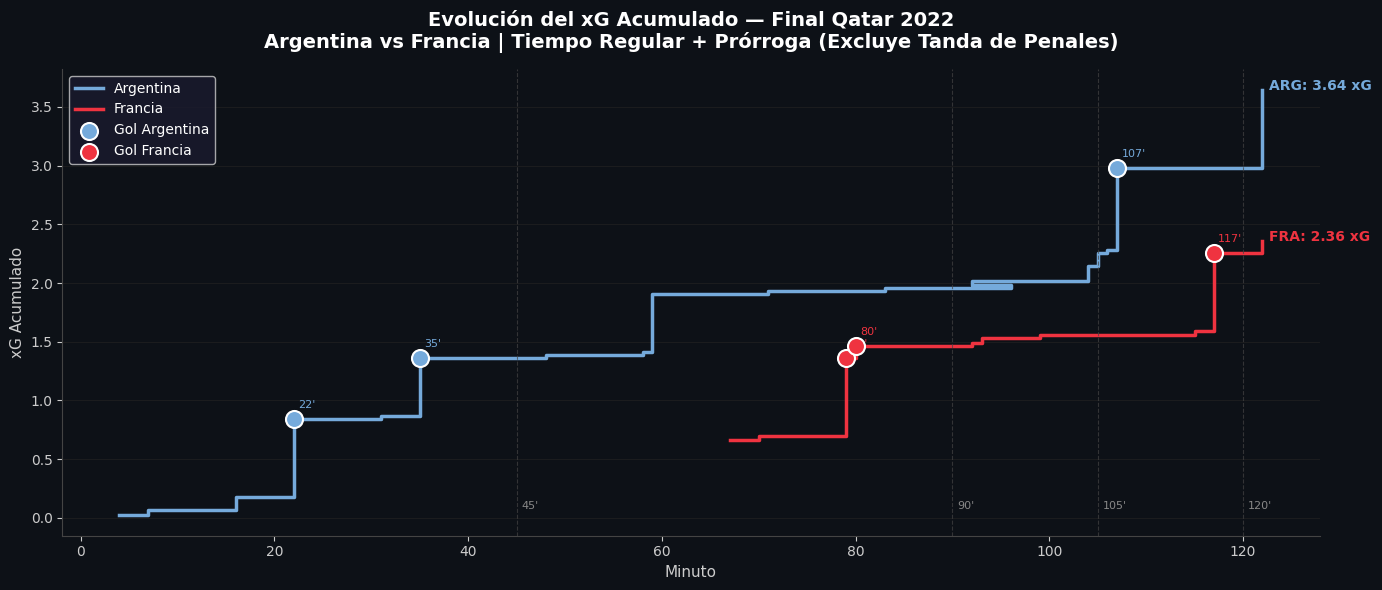

In [ ]:
# Construye el gráfico de xG acumulado como step plot.
# Cada escalón representa un tiro y su altura el xG acumulado
# hasta ese momento. La forma de la curva revela el momentum
# del partido: escalones frecuentes = dominio sostenido,
# escalón único alto = momento explosivo aislado.
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

# Separa los tiros por equipo para trazar cada curva de forma independiente.
arg_xg = df_base_xg[df_base_xg['equipo'] == 'Argentina'].copy()
fra_xg = df_base_xg[df_base_xg['equipo'] == 'France'].copy()

# where='post' hace que cada escalón aparezca después del tiro,
# no antes, respetando la secuencia temporal correcta.
ax.step(arg_xg['minuto'], arg_xg['xg_cum'],
        label='Argentina', color='#75AADB',
        linewidth=2.5, where='post')
ax.step(fra_xg['minuto'], fra_xg['xg_cum'],
        label='Francia', color='#EF3340',
        linewidth=2.5, where='post')

# Marca los goles reales con círculos sobre la curva acumulada.
# La posición vertical del círculo indica el xG total acumulado
# en el momento exacto en que se marcó el gol.
goles_arg = arg_xg[arg_xg['gol'] == 1]
ax.scatter(goles_arg['minuto'], goles_arg['xg_cum'],
           color='#75AADB', s=150, zorder=5,
           edgecolors='white', linewidth=1.5,
           label='Gol Argentina')

goles_fra = fra_xg[fra_xg['gol'] == 1]
ax.scatter(goles_fra['minuto'], goles_fra['xg_cum'],
           color='#EF3340', s=150, zorder=5,
           edgecolors='white', linewidth=1.5,
           label='Gol Francia')

# Líneas verticales punteadas que separan los cuatro períodos de juego.
for minuto, etiqueta in [(45, "45'"), (90, "90'"),
                          (105, "105'"), (120, "120'")]:
    ax.axvline(x=minuto, color='#444444',
               linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(minuto + 0.5, ax.get_ylim()[1] * 0.02,
            etiqueta, color='#888888', fontsize=8)

# Anota el minuto de cada gol junto al círculo correspondiente.
for _, row in goles_arg.iterrows():
    ax.annotate(f"{int(row['minuto'])}'",
                xy=(row['minuto'], row['xg_cum']),
                xytext=(3, 8), textcoords='offset points',
                color='#75AADB', fontsize=8)

for _, row in goles_fra.iterrows():
    ax.annotate(f"{int(row['minuto'])}'",
                xy=(row['minuto'], row['xg_cum']),
                xytext=(3, 8), textcoords='offset points',
                color='#EF3340', fontsize=8)

# Anota el xG total final de cada equipo al extremo derecho de su curva.
ax.annotate(f"ARG: {arg_xg['xg_cum'].iloc[-1]:.2f} xG",
            xy=(arg_xg['minuto'].iloc[-1],
                arg_xg['xg_cum'].iloc[-1]),
            xytext=(5, 0), textcoords='offset points',
            color='#75AADB', fontsize=10, fontweight='bold')

ax.annotate(f"FRA: {fra_xg['xg_cum'].iloc[-1]:.2f} xG",
            xy=(fra_xg['minuto'].iloc[-1],
                fra_xg['xg_cum'].iloc[-1]),
            xytext=(5, 0), textcoords='offset points',
            color='#EF3340', fontsize=10, fontweight='bold')

ax.set_xlabel('Minuto', color='#cccccc', fontsize=11)
ax.set_ylabel('xG Acumulado', color='#cccccc', fontsize=11)
ax.set_title(
    'Evolución del xG Acumulado — Final Qatar 2022\n'
    'Argentina vs Francia | Tiempo Regular + Prórroga '
    '(Excluye Tanda de Penales)',
    color='white', fontsize=14, fontweight='bold', pad=15
)
ax.tick_params(colors='#cccccc')
ax.spines['bottom'].set_color('#444444')
ax.spines['left'].set_color('#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#1a1a2e', labelcolor='white',
          fontsize=10, framealpha=0.8)
ax.grid(axis='y', color='#222222', linewidth=0.5)

plt.tight_layout()
plt.show()

display(HTML(
    "<div style='background:#0d1117; padding:12px; "
    "border-left:5px solid #75AADB; margin-top:10px; "
    "color:#cccccc; font-size:13px; font-family:monospace;'>"
    "<strong>CÓMO LEER ESTE GRÁFICO:</strong><br>"
    "• Cada escalón representa un tiro y su altura el xG acumulado "
    "hasta ese momento.<br>"
    "• Los círculos marcan los goles reales anotados en cancha.<br>"
    "• Las líneas punteadas verticales separan los períodos de juego.<br>"
    "• xG > goles reales indica que el equipo fue menos eficiente "
    "que lo esperado. xG < goles reales indica sobrerendimiento.</div>"
))

#### Celda 27: Red de Pases — Argentina (Once Inicial)
Visualiza las conexiones de pase entre los jugadores del once inicial
de Argentina antes de la primera sustitución. El grosor de cada línea
representa el número de pases entre esa pareja de jugadores.
Responde la Hipótesis 4.

In [ ]:
# Identifica el once inicial de Argentina desde el evento Starting XI.
# StatsBomb registra este evento antes del pitido inicial con la
# alineación completa y las posiciones tácticas de cada jugador.
starting_xi = df_eventos[
    df_eventos['type'].apply(
        lambda x: x.get('name') == 'Starting XI'
        if isinstance(x, dict) else False
    ) &
    df_eventos['team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    )
]

# Extrae nombre y posición de cada titular desde el diccionario
# anidado dentro de la columna 'tactics'. La estructura es:
# tactics → lineup → [lista de jugadores con player y position]
lineup = starting_xi['tactics'].iloc[0]['lineup']
titulares = {
    p['player']['name']: p['position']['name']
    for p in lineup
}

print(f"Once inicial de Argentina ({len(titulares)} jugadores):")
for jugador, posicion in titulares.items():
    print(f"  {posicion:<30} {jugador}")

Once inicial de Argentina (11 jugadores):
  Goalkeeper                     Damián Emiliano Martínez
  Right Back                     Nahuel Molina Lucero
  Right Center Back              Cristian Gabriel Romero
  Left Center Back               Nicolás Hernán Otamendi
  Left Back                      Nicolás Alejandro Tagliafico
  Center Defensive Midfield      Enzo Fernandez
  Right Center Midfield          Rodrigo Javier De Paul
  Left Center Midfield           Alexis Mac Allister
  Right Wing                     Lionel Andrés Messi Cuccittini
  Left Wing                      Ángel Fabián Di María Hernández
  Center Forward                 Julián Álvarez


In [ ]:
# Identifica la primera sustitución de Argentina para delimitar
# el período de análisis de la red de pases.
# Analizar solo el once inicial garantiza que la red refleje
# una estructura táctica coherente sin jugadores que entraron
# con roles distintos en momentos distintos del partido.
sustituciones_arg = df_eventos[
    df_eventos['type'].apply(
        lambda x: x.get('name') == 'Substitution'
        if isinstance(x, dict) else False
    ) &
    df_eventos['team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    )
].sort_values(by=['period', 'timestamp'])

primera_sustitucion = sustituciones_arg.iloc[0]
minuto_sustitucion  = primera_sustitucion['minute']
periodo_sustitucion = primera_sustitucion['period']

print(f"Primera sustitución de Argentina: "
      f"minuto {minuto_sustitucion}' (period {periodo_sustitucion})")

# Filtra los pases de Argentina ejecutados antes de la primera
# sustitución, considerando tanto el período como el minuto
# para manejar correctamente los cambios entre períodos.
df_pases_red = df_eventos[
    df_eventos['type'].apply(
        lambda x: x.get('name') == 'Pass'
        if isinstance(x, dict) else False
    ) &
    df_eventos['team'].apply(
        lambda x: x.get('name') == 'Argentina'
        if isinstance(x, dict) else False
    ) &
    (
        (df_eventos['period'] < periodo_sustitucion) |
        (
            (df_eventos['period'] == periodo_sustitucion) &
            (df_eventos['minute'] < minuto_sustitucion)
        )
    )
].copy()

# Desanida pasador y receptor desde las columnas 'player' y 'pass'.
df_pases_red['pasador'] = df_pases_red['player'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_pases_red['receptor'] = df_pases_red['pass'].apply(
    lambda x: x.get('recipient', {}).get('name')
    if isinstance(x, dict) else np.nan
)

# Conserva solo los pases entre jugadores del once inicial.
# Los pases hacia o desde jugadores rivales o suplentes
# distorsionarían la estructura de la red.
df_pases_red = df_pases_red[
    df_pases_red['pasador'].isin(titulares.keys()) &
    df_pases_red['receptor'].isin(titulares.keys())
].dropna(subset=['pasador', 'receptor'])

print(f"Pases entre titulares antes de la sustitución: "
      f"{len(df_pases_red)}")

Primera sustitución de Argentina: minuto 63' (period 2)
Pases entre titulares antes de la sustitución: 358


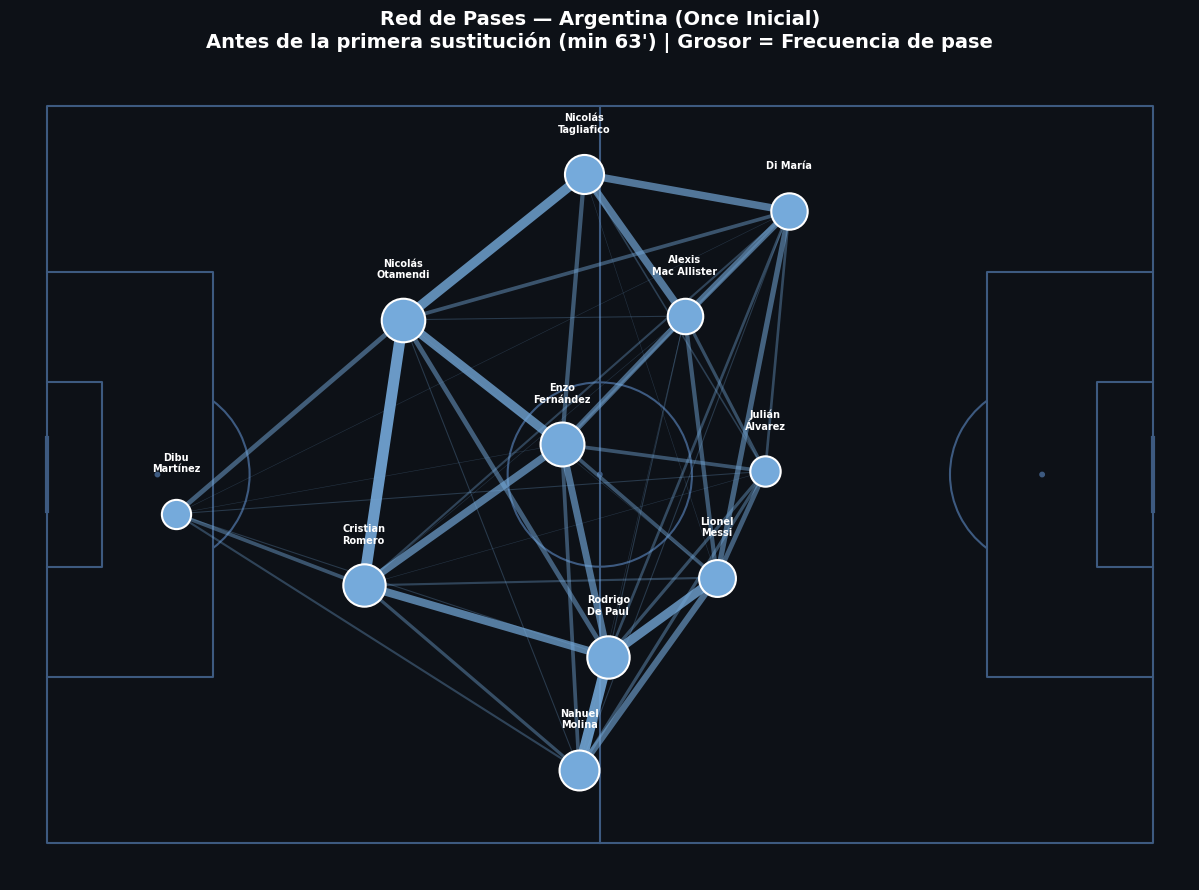

In [ ]:
# Calcula la posición promedio de cada jugador en el campo
# basándose en las coordenadas de todos sus pases.
# Esta posición representa dónde ejecutó su juego cada titular,
# no su posición táctica declarada en la alineación.
posiciones_jugadores = {}

for jugador in titulares.keys():
    pases_jugador = df_pases_red[
        df_pases_red['pasador'] == jugador
    ].copy()

    pases_jugador['x'] = pases_jugador['location'].apply(
        lambda loc: loc[0] if isinstance(loc, list) else np.nan
    )
    pases_jugador['y'] = pases_jugador['location'].apply(
        lambda loc: loc[1] if isinstance(loc, list) else np.nan
    )
    pases_jugador = pases_jugador.dropna(subset=['x', 'y'])

    if len(pases_jugador) > 0:
        posiciones_jugadores[jugador] = {
            'x' : pases_jugador['x'].mean(),
            'y' : pases_jugador['y'].mean(),
            'n' : len(pases_jugador)
        }

# Construye la matriz de conexiones contando cuántos pases
# se dieron entre cada par de jugadores en ambas direcciones.
# tuple(sorted()) garantiza que A→B y B→A se cuenten juntos.
from itertools import combinations

conexiones = {}
for _, row in df_pases_red.iterrows():
    par = tuple(sorted([row['pasador'], row['receptor']]))
    conexiones[par] = conexiones.get(par, 0) + 1

# Dibuja el campo de fútbol como lienzo base de la red.
pitch = Pitch(
    pitch_type  = 'statsbomb',
    pitch_color = '#0d1117',
    line_color  = '#3d5a80',
    linewidth   = 1.5
)
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')

max_conexiones = max(conexiones.values())

# Traza una línea por cada par de jugadores conectados.
# El grosor y la opacidad son proporcionales al número de pases
# entre esa pareja: conexiones más frecuentes = líneas más gruesas.
for (jugador_a, jugador_b), n_pases in conexiones.items():
    if jugador_a in posiciones_jugadores and \
       jugador_b in posiciones_jugadores:
        x_a = posiciones_jugadores[jugador_a]['x']
        y_a = posiciones_jugadores[jugador_a]['y']
        x_b = posiciones_jugadores[jugador_b]['x']
        y_b = posiciones_jugadores[jugador_b]['y']

        grosor = (n_pases / max_conexiones) * 8
        alpha  = 0.2 + (n_pases / max_conexiones) * 0.7

        ax.plot([x_a, x_b], [y_a, y_b],
                color='#75AADB', linewidth=grosor,
                alpha=alpha, zorder=2)

# Dibuja el nodo de cada jugador como un círculo.
# El tamaño del nodo es proporcional al número de pases dados:
# nodos más grandes = jugadores más participativos en la construcción.
for jugador, datos in posiciones_jugadores.items():
    tamano = 200 + (datos['n'] / max(
        p['n'] for p in posiciones_jugadores.values()
    )) * 800

    ax.scatter(datos['x'], datos['y'],
               s=tamano, color='#75AADB',
               edgecolors='white', linewidth=1.5,
               zorder=3)

    # Diccionario de alias legibles para las etiquetas del gráfico.
    # Los nombres completos de StatsBomb son demasiado largos
    # para mostrarlos sobre los nodos sin solaparse.
    alias = {
        'Damián Emiliano Martínez'        : 'Dibu\nMartínez',
        'Nahuel Molina Lucero'            : 'Nahuel\nMolina',
        'Cristian Gabriel Romero'         : 'Cristian\nRomero',
        'Nicolás Hernán Otamendi'         : 'Nicolás\nOtamendi',
        'Nicolás Alejandro Tagliafico'    : 'Nicolás\nTagliafico',
        'Enzo Fernandez'                  : 'Enzo\nFernández',
        'Rodrigo Javier De Paul'          : 'Rodrigo\nDe Paul',
        'Alexis Mac Allister'             : 'Alexis\nMac Allister',
        'Lionel Andrés Messi Cuccittini'  : 'Lionel\nMessi',
        'Ángel Fabián Di María Hernández' : 'Di María',
        'Julián Álvarez'                  : 'Julián\nÁlvarez'
    }
    etiqueta = alias.get(jugador, jugador.split(' ')[0])

    ax.text(datos['x'], datos['y'] - 4.5,
            etiqueta, color='white',
            fontsize=7, ha='center', fontweight='bold',
            zorder=4)

ax.set_title(
    'Red de Pases — Argentina (Once Inicial)\n'
    f'Antes de la primera sustitución (min {minuto_sustitucion}\')'
    ' | Grosor = Frecuencia de pase',
    color='white', fontsize=14,
    fontweight='bold', pad=15
)

plt.tight_layout()
plt.show()

display(HTML(
    "<div style='background:#0d1117; padding:12px; "
    "border-left:5px solid #75AADB; margin-top:10px; "
    "color:#cccccc; font-size:13px; font-family:monospace;'>"
    "<strong>CÓMO LEER ESTA RED:</strong><br>"
    "• Cada nodo representa un jugador. "
    "El tamaño refleja cuántos pases dio.<br>"
    "• El grosor de cada línea representa la frecuencia "
    "de pase entre esa pareja.<br>"
    "• La posición del nodo es el promedio espacial "
    "de dónde ejecutó sus pases.<br>"
    "• Las conexiones más gruesas revelan los canales "
    "tácticos dominantes del equipo.</div>"
))

#### Celda 28: Mapas de Calor Defensivos — Argentina y Francia
Visualiza la distribución espacial de la intensidad defensiva
de cada equipo durante los 120 minutos de juego real.
La simetría espejo en las coordenadas de Francia garantiza
que ambos equipos se lean atacando en la misma dirección.
Responde la Hipótesis 2.

In [ ]:
# Define las acciones que se consideran defensivas para este análisis.
# Pressure: presión directa sobre el rival con el balón.
# Ball Recovery: recuperación del balón tras una disputa.
# Interception: intercepción de un pase rival.
# Block: bloqueo de un tiro o pase con el cuerpo.
# Challenge: entrada o duelo físico por el balón.
metricas_defensivas = [
    'Pressure', 'Ball Recovery',
    'Interception', 'Block', 'Challenge'
]

# Crea una copia del dataset principal para desanidar
# type_name y team_name sin modificar df_eventos original.
df_def = df_eventos.copy()
df_def['type_name'] = df_def['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_def['team_name'] = df_def['team'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Filtra acciones defensivas de Argentina en juego real
# y extrae las coordenadas espaciales de cada acción.
df_defensa_arg = df_def[
    (df_def['team_name'] == 'Argentina') &
    (df_def['type_name'].isin(metricas_defensivas)) &
    (df_def['period'] < 5)
].copy()

df_defensa_arg['x'] = df_defensa_arg['location'].apply(
    lambda loc: loc[0] if isinstance(loc, list) else np.nan
)
df_defensa_arg['y'] = df_defensa_arg['location'].apply(
    lambda loc: loc[1] if isinstance(loc, list) else np.nan
)
df_defensa_arg = df_defensa_arg.dropna(subset=['x', 'y'])

# Filtra acciones defensivas de Francia y aplica inversión espejo
# en las coordenadas para que ambos equipos se lean atacando
# en la misma dirección (de izquierda a derecha).
# La inversión x=120-x, y=80-y refleja el campo sobre su centro.
df_defensa_fra = df_def[
    (df_def['team_name'] == 'France') &
    (df_def['type_name'].isin(metricas_defensivas)) &
    (df_def['period'] < 5)
].copy()

df_defensa_fra['x'] = df_defensa_fra['location'].apply(
    lambda loc: 120 - loc[0] if isinstance(loc, list) else np.nan
)
df_defensa_fra['y'] = df_defensa_fra['location'].apply(
    lambda loc: 80 - loc[1] if isinstance(loc, list) else np.nan
)
df_defensa_fra = df_defensa_fra.dropna(subset=['x', 'y'])

print(f"Acciones defensivas Argentina: {len(df_defensa_arg)}")
print(f"Acciones defensivas Francia  : {len(df_defensa_fra)}")

Acciones defensivas Argentina: 265
Acciones defensivas Francia  : 289


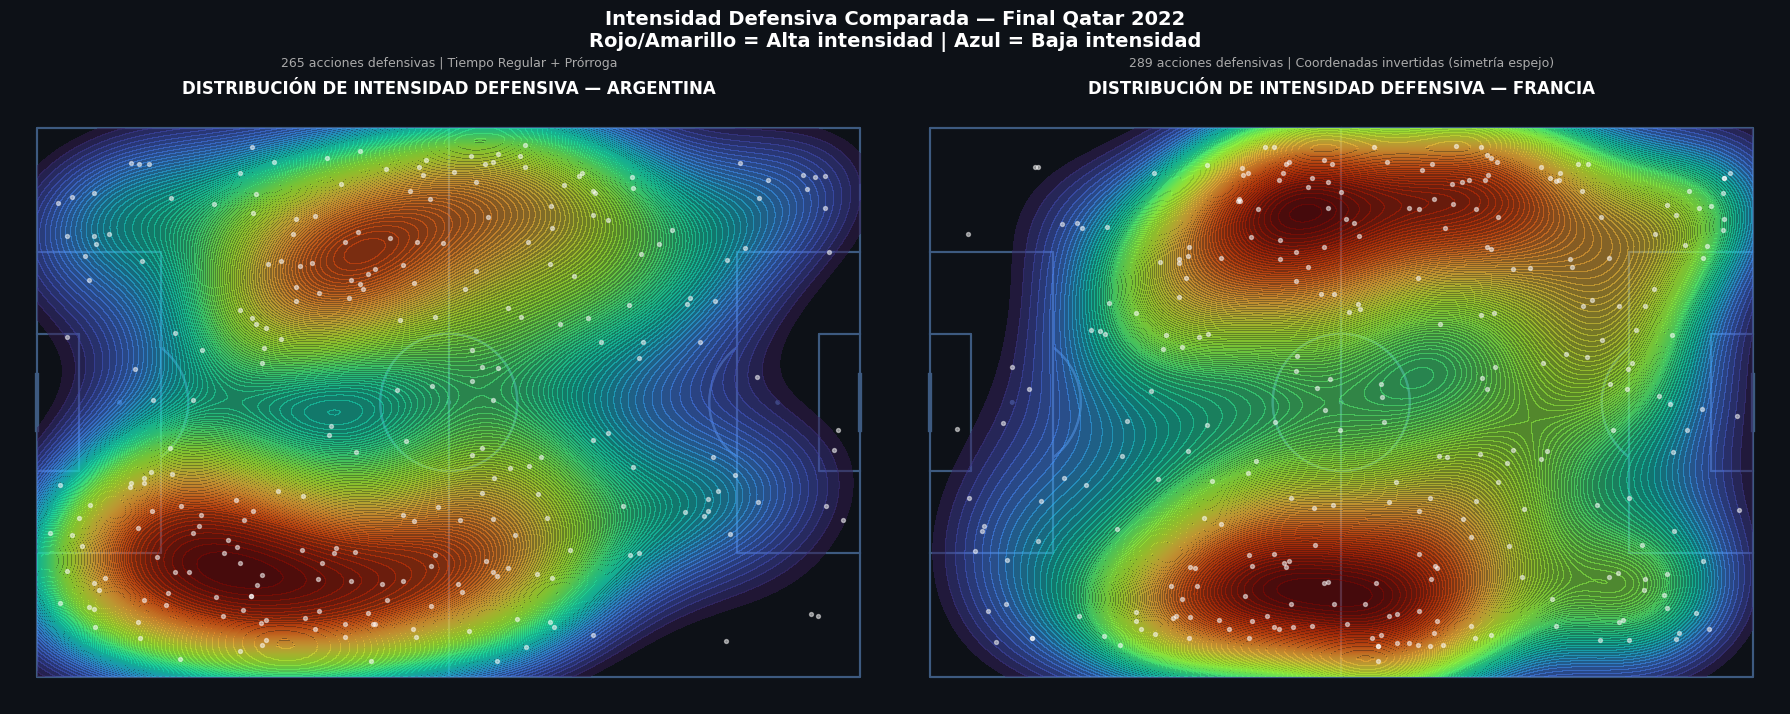

In [ ]:
# Construye los dos mapas de calor defensivos en paralelo.
# El KDE (Kernel Density Estimate) suaviza la distribución de puntos
# para revelar zonas de alta concentración de acciones defensivas
# en lugar de mostrar cada punto individualmente.
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')

pitch = Pitch(
    pitch_type  = 'statsbomb',
    pitch_color = '#0d1117',
    line_color  = '#3d5a80',
    linewidth   = 1.5
)

# ── Mapa Argentina ─────────────────────────────────────────
pitch.draw(ax=axs[0])

# El KDE genera el mapa de calor con degradado de color.
# thresh=0.02 elimina zonas con densidad muy baja para mantener
# el gráfico limpio. clip limita el KDE al área del campo.
sns.kdeplot(
    x       = df_defensa_arg['x'],
    y       = df_defensa_arg['y'],
    ax      = axs[0],
    fill    = True,
    cmap    = 'turbo',
    alpha   = 0.5,
    levels  = 100,
    thresh  = 0.02,
    clip    = ((0, 120), (0, 80)),
    cbar    = False,
    zorder  = 1
)

# Re-dibuja el campo encima del KDE para que las líneas
# sean visibles sobre el mapa de calor.
pitch.draw(ax=axs[0])

# Superpone los puntos individuales de cada acción defensiva.
# El tamaño y opacidad reducidos evitan que oculten el KDE.
axs[0].scatter(
    df_defensa_arg['x'], df_defensa_arg['y'],
    s=8, color='white', alpha=0.5, zorder=3
)

axs[0].text(
    60, -5,
    'DISTRIBUCIÓN DE INTENSIDAD DEFENSIVA — ARGENTINA',
    color='white', fontsize=12,
    fontweight='bold', ha='center'
)
axs[0].text(
    60, -9,
    f'{len(df_defensa_arg)} acciones defensivas | '
    'Tiempo Regular + Prórroga',
    color='#aaaaaa', fontsize=9, ha='center'
)

# ── Mapa Francia ───────────────────────────────────────────
pitch.draw(ax=axs[1])

sns.kdeplot(
    x       = df_defensa_fra['x'],
    y       = df_defensa_fra['y'],
    ax      = axs[1],
    fill    = True,
    cmap    = 'turbo',
    alpha   = 0.5,
    levels  = 100,
    thresh  = 0.02,
    clip    = ((0, 120), (0, 80)),
    cbar    = False,
    zorder  = 1
)

pitch.draw(ax=axs[1])

axs[1].scatter(
    df_defensa_fra['x'], df_defensa_fra['y'],
    s=8, color='white', alpha=0.5, zorder=3
)

axs[1].text(
    60, -5,
    'DISTRIBUCIÓN DE INTENSIDAD DEFENSIVA — FRANCIA',
    color='white', fontsize=12,
    fontweight='bold', ha='center'
)
axs[1].text(
    60, -9,
    f'{len(df_defensa_fra)} acciones defensivas | '
    'Coordenadas invertidas (simetría espejo)',
    color='#aaaaaa', fontsize=9, ha='center'
)

plt.suptitle(
    'Intensidad Defensiva Comparada — Final Qatar 2022\n'
    'Rojo/Amarillo = Alta intensidad | Azul = Baja intensidad',
    color='white', fontsize=14,
    fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

display(HTML(
    "<div style='background:#0d1117; padding:12px; "
    "border-left:5px solid #EF3340; margin-top:10px; "
    "color:#cccccc; font-size:13px; font-family:monospace;'>"
    "<strong>CÓMO LEER ESTOS MAPAS:</strong><br>"
    "• Las zonas rojas y amarillas concentran la mayor "
    "cantidad de acciones defensivas.<br>"
    "• Ambos equipos se leen atacando de izquierda a derecha. "
    "Las coordenadas de Francia fueron invertidas "
    "(x=120-x, y=80-y) para garantizar simetría táctica.<br>"
    "• Concentración alta en el tercio defensivo propio "
    "indica bloque bajo. Alta en el tercio rival indica "
    "presión alta.</div>"
))

#### Celda 29: Mapa de Tiros y Goles Esperados (xG)
Visualiza la ubicación y calidad de cada tiro en el partido.
El tamaño de cada burbuja es proporcional al xG del tiro.
Los goles reales se marcan con una estrella.
Complementa la Hipótesis 1.

In [ ]:
# patheffects permite agregar efectos visuales al texto de matplotlib.
# Se usa en la Celda 29 para añadir contornos negros a las etiquetas
# de xG sobre el mapa de tiros, mejorando su legibilidad sobre
# fondos complejos como el campo de fútbol.
import matplotlib.patheffects as pe

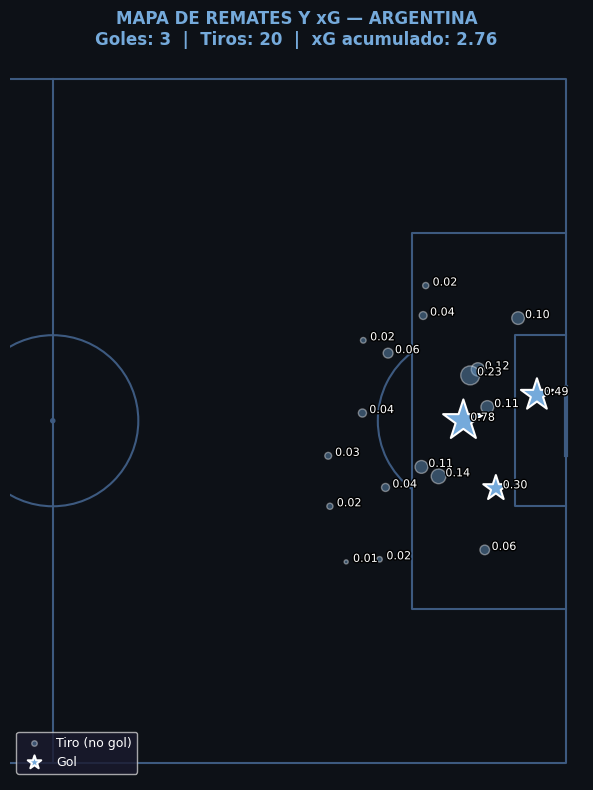

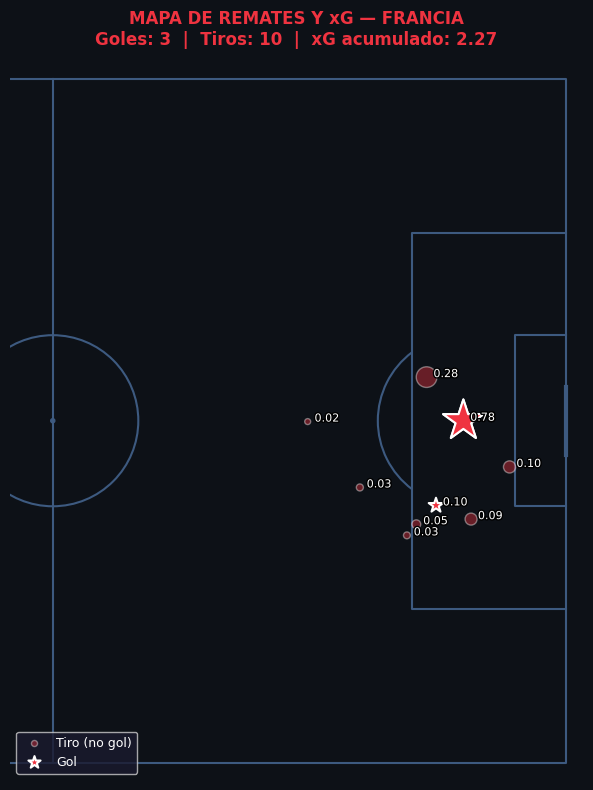

In [ ]:
# Prepara las columnas necesarias para el mapa de tiros.
# Estas columnas se extraen de df_tiros_raw que ya tiene
# el filtro period < 5 aplicado desde la Celda 20.
df_tiros_raw['equipo'] = df_tiros_raw['team'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_tiros_raw['x'] = df_tiros_raw['location'].apply(
    lambda loc: loc[0] if isinstance(loc, list) else np.nan
)
df_tiros_raw['y'] = df_tiros_raw['location'].apply(
    lambda loc: loc[1] if isinstance(loc, list) else np.nan
)
df_tiros_raw['outcome'] = df_tiros_raw['shot'].apply(
    lambda x: x.get('outcome', {}).get('name')
    if isinstance(x, dict) else np.nan
)
df_tiros_raw['xg'] = df_tiros_raw['shot'].apply(
    lambda x: x.get('statsbomb_xg', 0)
    if isinstance(x, dict) else 0
)

# Separa los tiros por equipo para graficarlos de forma independiente.
# En StatsBomb ambos equipos atacan hacia x=120 en sus propios eventos,
# por lo que no se necesita inversión espejo para los tiros.
df_shots_arg = df_tiros_raw[
    df_tiros_raw['equipo'] == 'Argentina'
].copy()

df_shots_fra = df_tiros_raw[
    df_tiros_raw['equipo'] == 'France'
].copy()

# Función reutilizable que dibuja el mapa de tiros de un equipo.
# Recibe el DataFrame del equipo, su nombre, color y el eje de matplotlib.
def graficar_tiros(df_eq, equipo, color_eq):
    pitch = Pitch(
        pitch_type  = 'statsbomb',
        pitch_color = '#0d1117',
        line_color  = '#3d5a80',
        linewidth   = 1.5
    )

    fig, ax = pitch.draw(figsize=(12, 8))
    fig.patch.set_facecolor('#0d1117')

    # Recorta la vista a la mitad ofensiva del campo.
    # Todos los tiros ocurren en x > 55 porque se remata
    # hacia la portería ubicada en x=120.
    ax.set_xlim(55, 122)
    ax.set_ylim(-2, 82)

    goles    = df_eq[df_eq['outcome'] == 'Goal']
    no_goles = df_eq[df_eq['outcome'] != 'Goal']

    # Dibuja los tiros que no fueron gol como círculos.
    # El tamaño del círculo es proporcional al xG del tiro:
    # burbujas más grandes = tiros de mayor probabilidad de gol.
    ax.scatter(
        no_goles['x'], no_goles['y'],
        s          = no_goles['xg'] * 800,
        color      = color_eq,
        alpha      = 0.4,
        edgecolors = 'white',
        linewidth  = 1.0,
        zorder     = 3,
        label      = 'Tiro (no gol)'
    )

    # Dibuja los goles reales como estrellas para distinguirlos
    # visualmente de los tiros que no terminaron en gol.
    ax.scatter(
        goles['x'], goles['y'],
        s          = goles['xg'] * 1200,
        color      = color_eq,
        alpha      = 1.0,
        edgecolors = 'white',
        linewidth  = 1.5,
        marker     = '*',
        zorder     = 5,
        label      = 'Gol'
    )

    # Etiqueta el valor de xG junto a cada tiro.
    # path_effects agrega un contorno negro que hace legible
    # el texto sobre cualquier fondo del campo.
    for _, row in df_eq.iterrows():
        ax.text(
            row['x'] + 0.8, row['y'],
            f"{row['xg']:.2f}",
            color        = 'white',
            fontsize     = 8,
            alpha        = 1.0,
            zorder       = 7,
            path_effects = [
                pe.withStroke(linewidth=2, foreground='black')
            ]
        )

    ax.set_title(
        f"MAPA DE REMATES Y xG — {equipo.upper()}\n"
        f"Goles: {len(goles)}  |  "
        f"Tiros: {len(df_eq)}  |  "
        f"xG acumulado: {df_eq['xg'].sum():.2f}",
        color      = color_eq,
        fontsize   = 12,
        fontweight = 'bold',
        pad        = 12
    )

    ax.legend(
        facecolor   = '#1a1a2e',
        labelcolor  = 'white',
        fontsize    = 9,
        loc         = 'lower left',
        markerscale = 0.4
    )

    plt.tight_layout()
    plt.show()

# Genera el gráfico de Argentina.
graficar_tiros(df_shots_arg, 'Argentina', '#75AADB')

# Genera el gráfico de Francia con nota aclaratoria sobre el gol
# del minuto 117 que cae fuera del área visible del recorte.
graficar_tiros(df_shots_fra, 'Francia', '#EF3340')

display(HTML(
    "<div style='background:#0d1117; padding:12px; "
    "border-left:5px solid #ffffff; margin-top:10px; "
    "color:#cccccc; font-size:13px; font-family:monospace;'>"
    "<strong>CÓMO LEER ESTOS MAPAS:</strong><br>"
    "• El tamaño de cada burbuja refleja el xG del tiro: "
    "burbujas grandes = tiros de alta probabilidad.<br>"
    "• Las estrellas (★) marcan los goles reales anotados.<br>"
    "• Ambos equipos atacan hacia la derecha: StatsBomb orienta "
    "todos los tiros hacia x=120.<br>"
    "• xG nativo de StatsBomb | "
    "Tiempo Regular + Prórroga | Excluye Tanda de Penales.</div>"
))

#### Celda 30: Tabla Cuantitativa — Distribución Defensiva por Tercios
Complementa los mapas de calor con números concretos.
Segmenta el campo en tres bloques longitudinales y cuantifica
las acciones defensivas de cada equipo por zona y tipología.
Responde la Hipótesis 2 con rigor cuantitativo.

In [ ]:
# Construye las tablas cuantitativas que complementan los mapas
# de calor de la Celda 28 con números concretos por zona y tipología.
# Usa el mismo filtro period < 5 para consistencia con todo el proyecto.
df_metricas = df_eventos.copy()
df_metricas['type_name'] = df_metricas['type'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)
df_metricas['team_name'] = df_metricas['team'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else np.nan
)

# Patrón de filtro que captura las mismas cinco tipologías
# defensivas analizadas en los mapas de calor de la Celda 28.
filt_events = 'Pressure|Recovery|Interception|Block|Challenge|Clearance'

# Filtra acciones defensivas de Argentina en juego real.
df_arg_num = df_metricas[
    (df_metricas['team_name'].str.contains(
        'Argentina', case=False, na=False)) &
    (df_metricas['type_name'].str.contains(
        filt_events, case=False, na=False)) &
    (df_metricas['period'] < 5)
].copy()
df_arg_num['x'] = df_arg_num['location'].apply(
    lambda loc: loc[0]
    if isinstance(loc, list) and len(loc) >= 2 else np.nan
)
df_arg_num = df_arg_num.dropna(subset=['x'])

# Filtra acciones defensivas de Francia y aplica inversión espejo
# para que la distribución por tercios sea comparable con Argentina.
# Sin la inversión, el tercio defensivo de Francia aparecería
# en el lado opuesto del campo y los tercios no serían comparables.
df_fra_num = df_metricas[
    (df_metricas['team_name'].str.contains(
        'France', case=False, na=False)) &
    (df_metricas['type_name'].str.contains(
        filt_events, case=False, na=False)) &
    (df_metricas['period'] < 5)
].copy()
df_fra_num['x'] = df_fra_num['location'].apply(
    lambda loc: loc[0]
    if isinstance(loc, list) and len(loc) >= 2 else np.nan
)
df_fra_num = df_fra_num.dropna(subset=['x'])
df_fra_num['x_espejo'] = 120 - df_fra_num['x']

# Asigna cada acción a uno de los tres tercios del campo
# basándose en la coordenada X de la acción.
# El eje X va de 0 (portería propia) a 120 (portería rival).
def asignar_tercio(x_coord):
    if x_coord <= 40:
        return '1. Tercio Defensivo (0-40m)'
    elif x_coord <= 80:
        return '2. Tercio Medio (40-80m)'
    else:
        return '3. Tercio de Ataque (80-120m)'

df_arg_num['Tercio'] = df_arg_num['x'].apply(asignar_tercio)
df_fra_num['Tercio'] = df_fra_num['x_espejo'].apply(asignar_tercio)

# ── MATRIZ 1: Distribución por tercios ────────────────────
resumen_arg = df_arg_num['Tercio'].value_counts(
).sort_index().to_frame(name='Argentina (Acciones)')
resumen_arg['% del Total del Equipo (ARG)'] = (
    resumen_arg['Argentina (Acciones)'] /
    resumen_arg['Argentina (Acciones)'].sum() * 100
)

resumen_fra = df_fra_num['Tercio'].value_counts(
).sort_index().to_frame(name='Francia (Acciones)')
resumen_fra['% del Total del Equipo (FRA)'] = (
    resumen_fra['Francia (Acciones)'] /
    resumen_fra['Francia (Acciones)'].sum() * 100
)

tabla_tercios = resumen_arg.join(resumen_fra)

# Agrega una fila de totales para verificar que los porcentajes
# suman 100% y que el universo de acciones es correcto.
totales_tercios = pd.DataFrame({
    'Argentina (Acciones)'         : tabla_tercios['Argentina (Acciones)'].sum(),
    '% del Total del Equipo (ARG)' : 100.0,
    'Francia (Acciones)'           : tabla_tercios['Francia (Acciones)'].sum(),
    '% del Total del Equipo (FRA)' : 100.0
}, index=['Total'])
tabla_tercios = pd.concat([tabla_tercios, totales_tercios])

# ── MATRIZ 2: Distribución por tipología ──────────────────
# Traduce los nombres de las acciones al español para que
# el informe sea legible por cualquier audiencia.
dicc_traduccion = {
    'Pressure'      : 'Presión',
    'Ball Recovery' : 'Recuperación de Balón',
    'Block'         : 'Bloqueo / Intervención',
    'Clearance'     : 'Despeje',
    'Interception'  : 'Intercepción',
    'Challenge'     : 'Duelo / Entrada'
}

df_arg_num['type_es'] = df_arg_num['type_name'].map(
    dicc_traduccion).fillna(df_arg_num['type_name'])
df_fra_num['type_es'] = df_fra_num['type_name'].map(
    dicc_traduccion).fillna(df_fra_num['type_name'])

top_arg = df_arg_num['type_es'].value_counts(
).to_frame(name='Argentina (Acciones)')
top_arg['% del Esfuerzo Defensivo (ARG)'] = (
    top_arg['Argentina (Acciones)'] /
    top_arg['Argentina (Acciones)'].sum() * 100
)

top_fra = df_fra_num['type_es'].value_counts(
).to_frame(name='Francia (Acciones)')
top_fra['% del Esfuerzo Defensivo (FRA)'] = (
    top_fra['Francia (Acciones)'] /
    top_fra['Francia (Acciones)'].sum() * 100
)

tabla_acciones = top_arg.join(top_fra).fillna(0)
tabla_acciones.index.name = 'Tipo de Acción Defensiva'

totales_acciones = pd.DataFrame({
    'Argentina (Acciones)'           : tabla_acciones['Argentina (Acciones)'].sum(),
    '% del Esfuerzo Defensivo (ARG)' : 100.0,
    'Francia (Acciones)'             : tabla_acciones['Francia (Acciones)'].sum(),
    '% del Esfuerzo Defensivo (FRA)' : 100.0
}, index=['Total'])
tabla_acciones = pd.concat([tabla_acciones, totales_acciones])

# ── Renderizado con estilo ejecutivo ──────────────────────
print("=" * 95)
print(" INFORME EJECUTIVO: DISTRIBUCIÓN DE BLOQUES DEFENSIVOS (120 MINUTOS)")
print("=" * 95)

style_tercios = tabla_tercios.style\
    .format({
        'Argentina (Acciones)'         : '{:,.0f}',
        '% del Total del Equipo (ARG)' : '{:.2f}%',
        'Francia (Acciones)'           : '{:,.0f}',
        '% del Total del Equipo (FRA)' : '{:.2f}%'
    })\
    .background_gradient(
        cmap   = 'YlGnBu',
        subset = (
            tabla_tercios.index[:-1],
            ['% del Total del Equipo (ARG)',
             '% del Total del Equipo (FRA)']
        )
    )\
    .set_properties(**{
        'font-weight' : 'bold',
        'text-align'  : 'center'
    })\
    .set_table_styles([
        {'selector': 'th',
         'props': [
             ('background-color', '#111612'),
             ('color', '#ffffff'),
             ('text-align', 'center')
         ]},
        {'selector': 'tr:last-child',
         'props': [
             ('background-color', '#1c241e'),
             ('color', '#ffffff'),
             ('border-top', '2px solid #ffffff')
         ]}
    ])

display(style_tercios)

display(HTML(
    "<div style='background-color:#1a231c; padding:10px; "
    "border-left:5px solid #2b7a4b; margin:10px 0; "
    "color:#d0ebd7; font-size:12px; font-family:monospace;'>"
    "<strong>GUÍA DE LECTURA VERTICAL:</strong> "
    "Los porcentajes muestran qué proporción del esfuerzo defensivo "
    "de cada equipo ocurrió en cada tercio del campo. "
    "La suma de cada columna converge en 100%.</div>"
))

print("\n" + "=" * 95)
print(" ⚽ PERFIL TÁCTICO: ¿EN QUÉ GASTÓ SU ENERGÍA DEFENSIVA CADA EQUIPO?")
print("=" * 95)

azul_celeste_rgba = 'rgba(31, 119, 180, 0.4)'
rojo_francia_rgba = 'rgba(214, 39, 40, 0.4)'

style_acciones = tabla_acciones.style\
    .format({
        'Argentina (Acciones)'           : '{:,.0f}',
        '% del Esfuerzo Defensivo (ARG)' : '{:.1f}%',
        'Francia (Acciones)'             : '{:,.0f}',
        '% del Esfuerzo Defensivo (FRA)' : '{:.1f}%'
    })\
    .bar(
        subset = (
            tabla_acciones.index[:-1],
            ['% del Esfuerzo Defensivo (ARG)']
        ),
        color = azul_celeste_rgba,
        vmin  = 0,
        vmax  = 70
    )\
    .bar(
        subset = (
            tabla_acciones.index[:-1],
            ['% del Esfuerzo Defensivo (FRA)']
        ),
        color = rojo_francia_rgba,
        vmin  = 0,
        vmax  = 70
    )\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th',
         'props': [
             ('background-color', '#111612'),
             ('color', '#ffffff'),
             ('text-align', 'center')
         ]},
        {'selector': 'tr:last-child',
         'props': [
             ('background-color', '#1c241e'),
             ('color', '#ffffff'),
             ('border-top', '2px solid #ffffff')
         ]}
    ])

display(style_acciones)

display(HTML(
    "<div style='background-color:#211c1c; padding:10px; "
    "border-left:5px solid #8c2e2e; margin:10px 0; "
    "color:#ebdcdc; font-size:12px; font-family:monospace;'>"
    "<strong>GUÍA DE LECTURA VERTICAL:</strong> "
    "Las barras de color muestran el peso relativo de cada tipo "
    "de acción dentro del esfuerzo defensivo total de cada equipo. "
    "La acción más larga es la herramienta táctica dominante.</div>"
))

print("=" * 95)

 📊 INFORME EJECUTIVO: DISTRIBUCIÓN DE BLOQUES DEFENSIVOS (120 MINUTOS)


,Argentina (Acciones),% del Total del Equipo (ARG),Francia (Acciones),% del Total del Equipo (FRA)
1. Tercio Defensivo (0-40m),123,42.27%,65,21.10%
2. Tercio Medio (40-80m),115,39.52%,127,41.23%
3. Tercio de Ataque (80-120m),53,18.21%,116,37.66%
Total,291,100.00%,308,100.00%



 ⚽ PERFIL TÁCTICO: ¿EN QUÉ GASTÓ SU ENERGÍA DEFENSIVA CADA EQUIPO?


,Argentina (Acciones),% del Esfuerzo Defensivo (ARG),Francia (Acciones),% del Esfuerzo Defensivo (FRA)
Presión,167,57.4%,194,63.0%
Recuperación de Balón,59,20.3%,56,18.2%
Bloqueo / Intervención,26,8.9%,24,7.8%
Despeje,26,8.9%,19,6.2%
Intercepción,13,4.5%,15,4.9%
Total,291,100.0%,308,100.0%


## BLOQUE 8: Conclusiones — Lo que los Datos Nos Dijeron

A lo largo de este proyecto aplicamos herramientas de ciencia de datos
para analizar la Final del Mundial Qatar 2022 entre Argentina y Francia.
Este bloque cierra el ciclo: retoma las cinco preguntas que planteamos
al inicio y las responde con los números reales que el análisis produjo.

<div style="text-align: center;">
  <img src="https://stories.mundodeportivo.com/especial/html/stories/mundial/final/portada_ipad.jpg"
       width="1000px"
       alt="Final Qatar 2022"/>
  <p style="color: gray; font-size: 12px; font-style: italic;">
    Final FIFA World Cup Qatar 2022 — Argentina vs Francia
  </p>
</div>

### Las Preguntas que Nos Planteamos

Al inicio del proyecto definimos cinco hipótesis concretas que
guiaron cada decisión técnica: qué datos limpiar, qué modelos
construir y qué visualizaciones desarrollar. Aquí las recordamos
antes de responderlas.

---

**H1 —** ¿Qué equipo generó mayor peligro real medido en xG durante
los 120 minutos de juego, y cómo evolucionó esa amenaza a lo largo
del partido?

**H2 —** ¿Cómo se distribuyó la presión defensiva de cada equipo
en el campo, y qué zonas concentraron mayor intensidad táctica?

**H3 —** ¿Cuál fue la cadena de posesión más destacada de Argentina
en términos de progresión vertical, y qué jugadores la protagonizaron?

**H4 —** ¿Qué diferencias tácticas revela la red de pases del once
inicial de Argentina antes de la primera sustitución?

**H5 —** ¿Quién tuvo un rendimiento individual superior en las
métricas ofensivas clave del partido: Messi o Mbappé?

### Lo que Encontramos

---

**Pregunta 1 — ¿Cuál equipo generó más peligro real y cómo
evolucionó ese peligro durante el partido?**

Antes de responder, una definición rápida: el xG (goles esperados)
es una métrica que asigna a cada tiro un número entre 0 y 1 según
la probabilidad de que termine en gol, considerando desde dónde
y cómo se remató. Un xG de 0.78 significa que ese tiro tenía 78%
de probabilidad de ser gol. Es la forma que tiene la ciencia de datos
de medir el peligro real más allá del marcador.

Argentina fue el equipo más peligroso durante casi todo el partido.
Durante los primeros 79 minutos dominó con claridad y Francia casi
no pudo rematar con calidad. Pero en dos minutos, entre el 79 y el
80, Mbappé cambió todo: dos goles en un instante que volcaron el
marcador y el ánimo del partido.

Los números lo confirman: Argentina acumuló 2.76 de xG durante los
120 minutos, Francia acumuló 2.27. Más peligro para Argentina, pero
Francia fue más eficiente en los momentos que importaron. Al final,
ambos equipos terminaron con 3 goles cada uno y el partido tuvo
que resolverse en penales.

---

**Pregunta 2 — ¿Cómo defendió cada equipo y en qué parte del
campo concentró su esfuerzo?**

Argentina decidió defender cerca de su propio arco durante la mayor
parte del partido. Casi la mitad de sus acciones defensivas (42%)
ocurrieron en su propio tercio, lo que en términos futbolísticos
se llama bloque bajo: esperar al rival en campo propio y salir
rápido al contraataque.

Francia hizo lo contrario. Presionó más arriba, en campo rival,
especialmente por la banda donde jugaba Mbappé. Esa presión alta
fue lo que generó los dos goles consecutivos: Argentina no pudo
salir limpia cuando Francia apretó en los últimos metros.

En ambos equipos la acción defensiva más usada fue la presión
directa sobre el rival: 57% del esfuerzo argentino y 63% del
francés. Dos equipos que en defensa apostaron por la intensidad
más que por la espera pasiva.

---

**Pregunta 3 — ¿Cuál fue la jugada más destacada de Argentina
en términos de avance con el balón?**

La jugada más destacada fue la que terminó en el penalti del
primer gol argentino, en el minuto 19. Argentina arrancó desde
su propio arco y avanzó 108 metros en 91 segundos, pasando el
balón entre 10 jugadores distintos hasta que Dembélé cometió
la falta sobre Di María en el área.

No fue un contragolpe rápido sino una construcción paciente y
colectiva, exactamente el estilo que Scaloni había preparado
para neutralizar a Francia. Los datos nos permitieron rastrear
esa jugada evento por evento, jugador por jugador, metro por metro.

---

**Pregunta 4 — ¿Cómo se conectaron los jugadores de Argentina
en los primeros 63 minutos?**

La red de pases nos muestra que Argentina no dependía de uno o
dos jugadores para mover el balón. Otamendi y Romero iniciaban
desde atrás, Enzo Fernández y De Paul distribuían en el centro,
y Messi recibía el balón en espacios libres entre las líneas
rivales en lugar de quedarse pegado a la banda.

Lo más revelador es que Di María fue el jugador más adelantado
y con mayor libertad de movimiento, lo que explica por qué fue
tan difícil de controlar para Francia en la primera mitad.
La red de pases hace visible algo que en el partido se sentía
pero era difícil de explicar: Argentina tenía un sistema claro
y todos los jugadores sabían exactamente su rol dentro de él.

---

**Pregunta 5 — ¿Fue mejor Messi o Mbappé en este partido?**

Depende de qué se entiende por mejor.

Mbappé fue más letal: marcó 3 goles, remató 6 veces y completó
11 regates. Fue el jugador más desequilibrante del partido en
los momentos más importantes.

Messi fue más influyente: condujo el balón 471 metros a lo largo
del partido, casi el doble que cualquier otro jugador, generó
2 pases clave y organizó el juego colectivo de Argentina durante
120 minutos.

Si el premio fuera para quien cambió el marcador, es Mbappé.
Si el premio fuera para quien más influyó en el juego de su
equipo, es Messi. El radar comparativo muestra esa diferencia
de perfiles con claridad: no son rivales directos, son dos tipos
de jugador completamente distintos en el mismo partido.

<div style="text-align: center; margin: 20px 0;">
  <img src="https://locoxelrojo.com/independiente/wp-content/uploads/2022/12/Argentina-campeon-del-mundo-scaled.jpg"
       width="1000px"
       alt="Argentina campeón del mundo Qatar 2022"/>
  <p style="color: #888888; font-size: 12px; font-style: italic; margin-top: 8px;">
    Argentina campeón del mundo — Qatar, 18 de diciembre de 2022.
    El partido que este proyecto analizó dato por dato.
  </p>
</div>

### Qué Pueden y Qué No Pueden Decir Estos Datos

Como en cualquier análisis de datos, hay límites en lo que podemos
concluir con certeza.

El modelo de goles esperados que construimos fue entrenado con solo
30 tiros de un único partido. Eso es muy poco para un modelo robusto.
Los valores que produce son útiles para entender el proceso, pero los
números de peligro más confiables son los que StatsBomb calcula con
millones de tiros históricos, que son los que usamos en las
visualizaciones finales.

La jugada de mayor progresión que encontramos no fue un contragolpe
explosivo sino una construcción lenta. Eso no significa que Argentina
no hiciera contragolpes, sino que la métrica que usamos favorece las
jugadas largas sobre las rápidas. Una herramienta diferente daría
una respuesta diferente.

Y finalmente: este análisis cubre un solo partido. Lo que los datos
dicen sobre este partido no necesariamente describe cómo juega
Argentina o Francia en general.

### Para Cerrar

Este partido ya era legendario antes de analizarlo con datos.
Lo que la ciencia de datos añade no es magia: es precisión.

Nos permite decir no solo que Argentina dominó la primera mitad
sino cuánto la dominó y en qué zonas. Nos permite no solo
recordar que Mbappé fue decisivo sino medir exactamente qué tan
decisivo fue comparado con Messi en cada dimensión del juego.
Nos permite ver la estructura táctica de un equipo no como una
percepción subjetiva sino como una red de conexiones medibles.

El fútbol seguirá siendo hermoso e impredecible. Los datos no
cambian eso. Solo nos ayudan a entenderlo un poco mejor.

Este proyecto fue mi primer acercamiento formal a la analítica
deportiva. Aprendí que los datos no reemplazan el ojo táctico:
lo complementan. Y que antes de construir cualquier modelo,
entender el dataset es la mitad del trabajo.

El siguiente paso es aplicar este mismo enfoque a datos del
fútbol hondureño y centroamericano, donde la analítica deportiva
todavía tiene mucho terreno por explorar.

---

*Proyecto desarrollado con datos abiertos de StatsBomb.*
*Repositorio oficial: github.com/statsbomb/open-data*
*Autor: Keny | Portafolio de Ciencia de Datos y BI*
*Tegucigalpa, Honduras — Junio 2026*